## Exploratory EOF analysis

In [1]:
# Setup: config + imports
import glob
import os
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature

OUT_DIR      = "../Figures/no-coslat"
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
import xarray as xr

detr_field = xr.open_dataarray("detr_field.nc")
detr_field

<xarray.DataArray (time: 276, lat: 36, lon: 61)> Size: 5MB
[606096 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2025-12-01
  * lat      (lat) float32 144B 14.5 15.5 16.5 17.5 18.5 ... 46.5 47.5 48.5 49.5
  * lon      (lon) float32 244B -126.5 -125.5 -124.5 ... -68.5 -67.5 -66.5

Mode 1: 81.8% of variance
Mode 2: 7.8% of variance
Mode 3: 3.5% of variance
Mode 4: 1.3% of variance
Mode 5: 0.9% of variance
Mode 6: 0.6% of variance
Mode 7: 0.5% of variance
Mode 8: 0.4% of variance
Mode 9: 0.3% of variance
Mode 10: 0.3% of variance
Mode 11: 0.2% of variance
Mode 12: 0.2% of variance
Mode 13: 0.1% of variance
Mode 14: 0.1% of variance
Mode 15: 0.1% of variance
Mode 16: 0.1% of variance
Mode 17: 0.1% of variance
Mode 18: 0.1% of variance
Mode 19: 0.1% of variance
Mode 20: 0.1% of variance
Mode 21: 0.1% of variance
Mode 22: 0.1% of variance
Mode 23: 0.1% of variance
Mode 24: 0.0% of variance
Mode 25: 0.0% of variance
Mode 26: 0.0% of variance
Mode 27: 0.0% of variance
Mode 28: 0.0% of variance
Mode 29: 0.0% of variance
Mode 30: 0.0% of variance
Mode 31: 0.0% of variance
Mode 32: 0.0% of variance
Mode 33: 0.0% of variance
Mode 34: 0.0% of variance
Mode 35: 0.0% of variance
Mode 36: 0.0% of variance
Mode 37: 0.0% of variance
Mode 38: 0.0% of variance
Mode 39: 0.0% of var

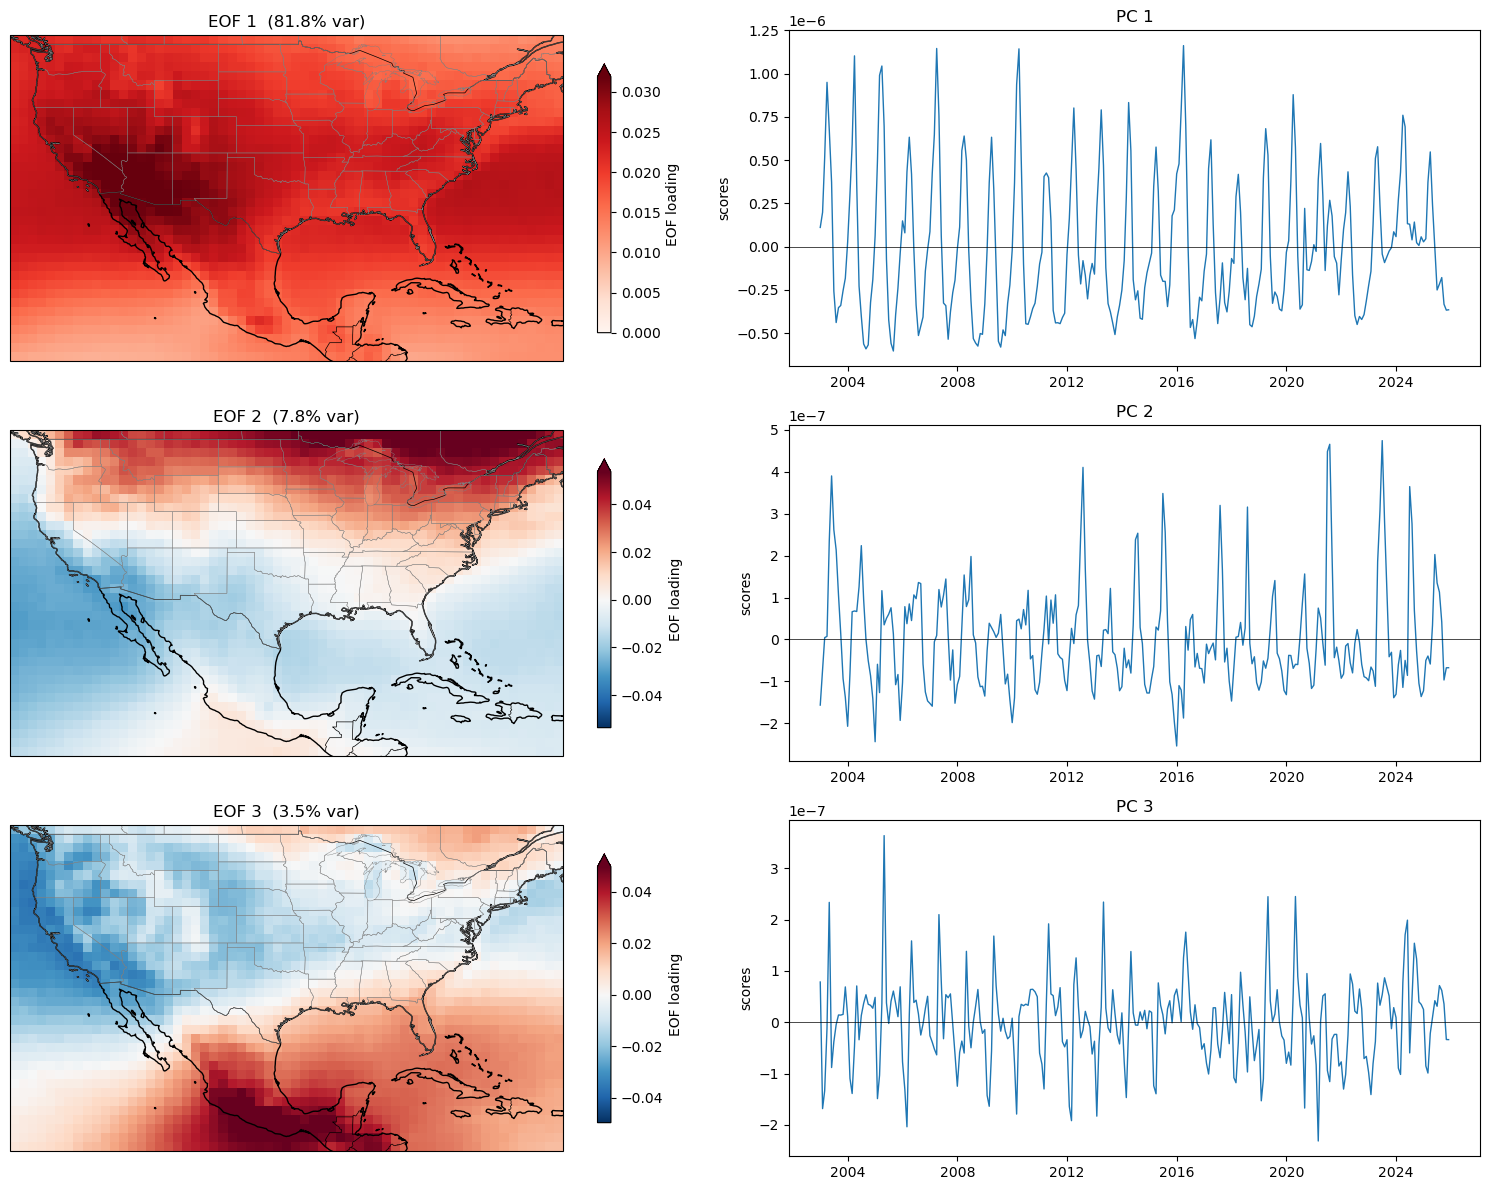

Saved -> ../Figures/no-coslat\eof_detrended_2003_2025.png


In [3]:
# EOF on the per-pixel detrended field 
from xeofs.single import EOF

model = EOF(n_modes=276, use_coslat=False)
model.fit(detr_field, dim="time")
eofs   = model.components()                       # (mode, lat, lon)
pcs    = model.scores()                           # (mode, time)
expvar = model.explained_variance_ratio().values * 100
for i, v in enumerate(expvar, start=1):
    print(f"Mode {i}: {v:.1f}% of variance")

# --- pick a diverging (RdBu_r) or sequential colormap per mode, based on
#     whether the loading actually contains both signs ------------------------
def choose_cmap_and_range(data, robust=True, plow=2, phigh=98):
    """robust=True clips to the [plow, phigh] percentile range before deciding
    sign/extent, same spirit as xarray's robust=True, so a single wild outlier
    pixel can't blow out the whole color scale."""
    vals = np.asarray(data)
    vals = vals[np.isfinite(vals)]
    if robust:
        lo, hi = np.nanpercentile(vals, [plow, phigh])
    else:
        lo, hi = np.nanmin(vals), np.nanmax(vals)

    has_pos, has_neg = hi > 0, lo < 0

    if has_pos and has_neg:
        vext = max(abs(lo), abs(hi))          # symmetric range -> 0 sits at the colormap center
        return "RdBu_r", -vext, vext
    elif has_pos:                              # all positive: no reason to reserve half the
        return "Reds", 0.0, hi                 # colormap for a blue that will never appear
    else:                                       # all negative
        return "Blues_r", lo, 0.0

# Plot first 3 modes: spatial pattern + PC.
n_show = 3
fig_eof = plt.figure(figsize=(15, 4 * n_show))
for i in range(n_show):
    eof_i = eofs.sel(mode=i+1)
    cmap_i, vmin_i, vmax_i = choose_cmap_and_range(eof_i.values)

    ax_map = fig_eof.add_subplot(n_show, 2, 2*i + 1, projection=ccrs.PlateCarree())
    eof_i.plot(
        ax=ax_map, transform=ccrs.PlateCarree(), cmap=cmap_i,
        vmin=vmin_i, vmax=vmax_i,
        cbar_kwargs={"label": "EOF loading", "shrink": 0.8},
    )
    ax_map.coastlines()
    ax_map.add_feature(cfeature.BORDERS, lw=0.5)
    ax_map.add_feature(cfeature.STATES, lw=0.3, edgecolor="gray")
    ax_map.set_title(f"EOF {i+1}  ({expvar[i]:.1f}% var)")

    ax_pc = fig_eof.add_subplot(n_show, 2, 2*i + 2)
    pcs.sel(mode=i+1).plot(ax=ax_pc, lw=1)
    ax_pc.axhline(0, color="k", lw=0.5)
    ax_pc.set_title(f"PC {i+1}")
    ax_pc.set_xlabel("")

plt.tight_layout()
out_eof = os.path.join(OUT_DIR, "eof_detrended_2003_2025.png")
fig_eof.savefig(out_eof, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_eof)

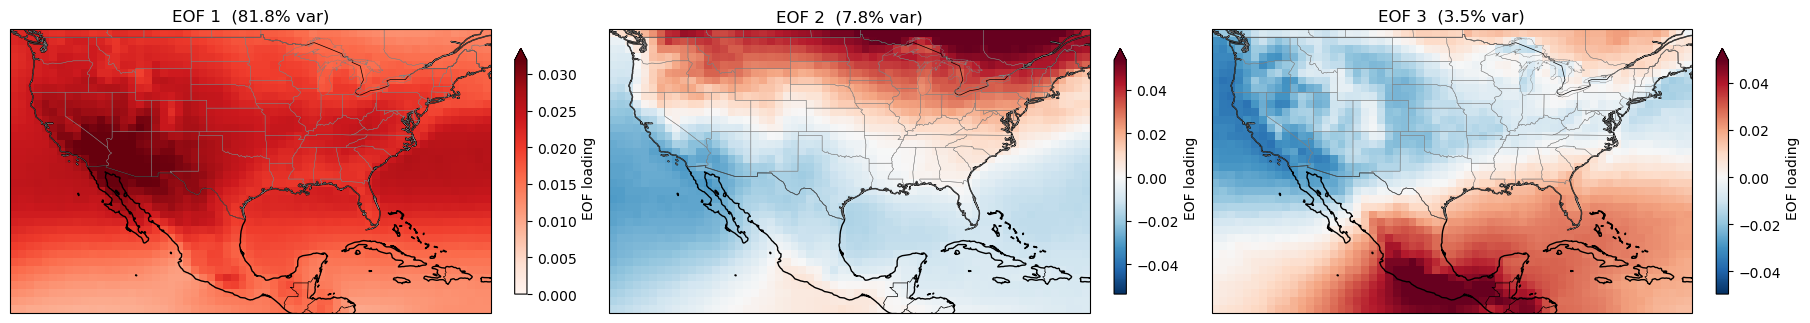

Saved -> ../Figures/no-coslat\eof_maps_only_2003_2025.png


In [4]:
# --- plot only the spatial EOF patterns (maps) for the first 3 modes, no PCs ---
n_show = 3
fig_eof_maps, axes_eof_maps = plt.subplots(
    1, n_show, figsize=(6 * n_show, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True,
)

for i, ax_map in enumerate(axes_eof_maps):
    eof_i = eofs.sel(mode=i+1)
    cmap_i, vmin_i, vmax_i = choose_cmap_and_range(eof_i.values)

    eof_i.plot(
        ax=ax_map, transform=ccrs.PlateCarree(), cmap=cmap_i,
        vmin=vmin_i, vmax=vmax_i,
        cbar_kwargs={"label": "EOF loading", "shrink": 0.5},
    )
    ax_map.coastlines()
    ax_map.add_feature(cfeature.BORDERS, lw=0.5)
    ax_map.add_feature(cfeature.STATES, lw=0.3, edgecolor="gray")
    ax_map.set_title(f"EOF {i+1}  ({expvar[i]:.1f}% var)")

out_eof_maps = os.path.join(OUT_DIR, "eof_maps_only_2003_2025.png")
fig_eof_maps.savefig(out_eof_maps, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_eof_maps)

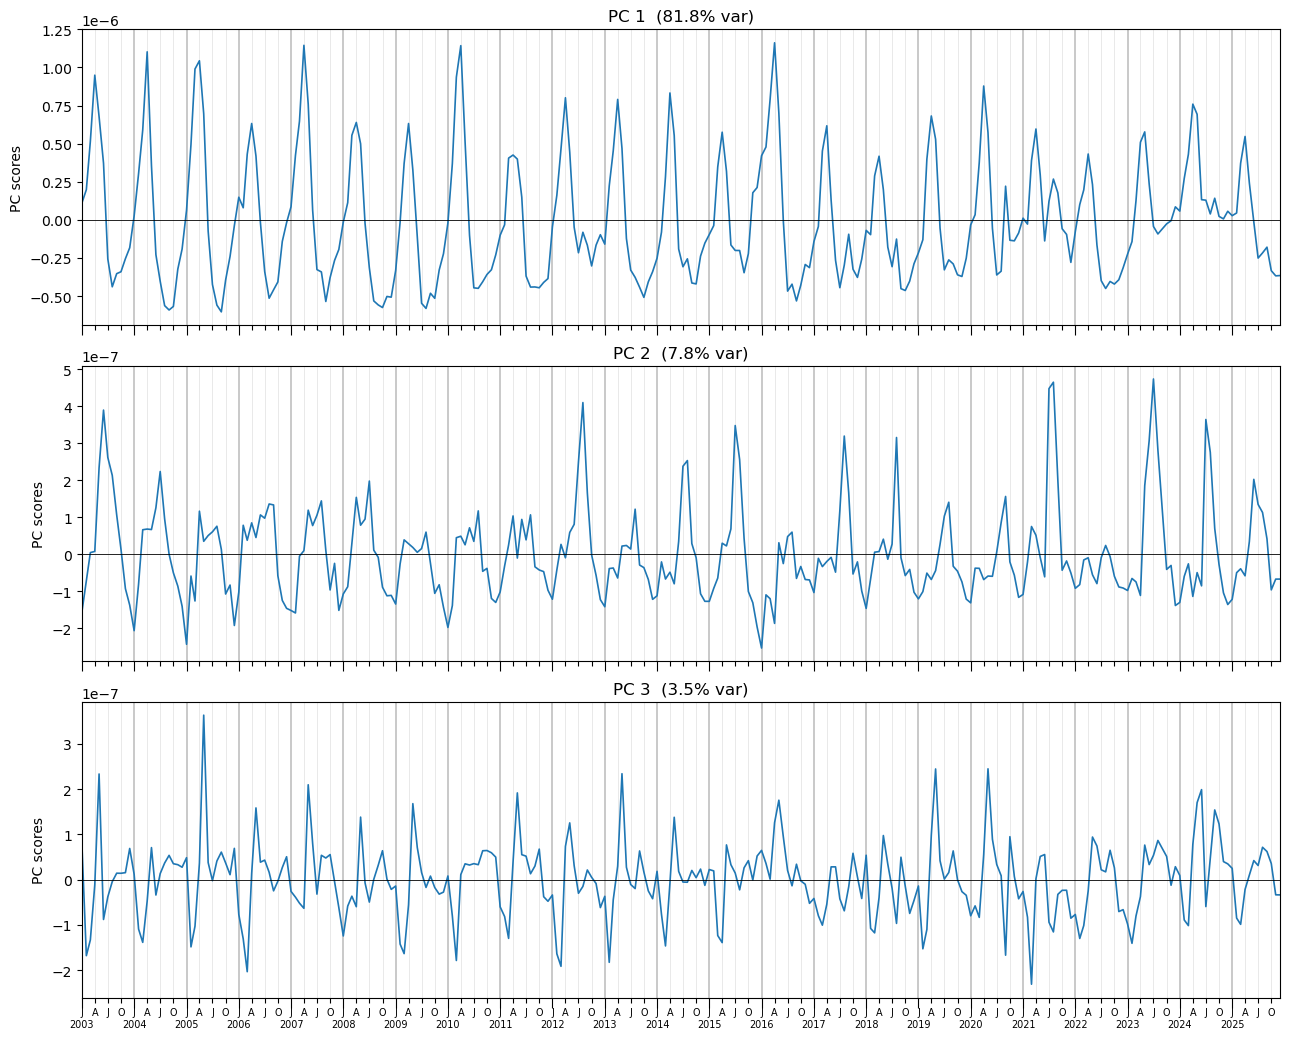

Saved -> ../Figures/no-coslat\eof_pcs_1to3_2003_2025.png


In [5]:
# --- inspect the first three normal-EOF PCs, same axis style as the box reconstructions ---
pc_months = pd.to_datetime(pcs["time"].values)

quarter_mask_pc = pc_months.month.isin([1, 4, 7, 10])
tick_dates_pc = pc_months[quarter_mask_pc]
jan_mask_pc = tick_dates_pc.month == 1

labels_pc = []
for d in tick_dates_pc:
    letter = d.strftime("%b")[0]          # J, A, J, O
    if d.month == 1:
        labels_pc.append(f"{letter}\n{d.year}")
    else:
        labels_pc.append(letter)

fig_pcs, axes_pcs = plt.subplots(3, 1, figsize=(13, 3.5 * 3), sharex=True)

for i, ax in enumerate(axes_pcs, start=1):
    ax.plot(pc_months, pcs.sel(mode=i).values, lw=1.2, color="#1f77b4")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"PC {i}  ({expvar[i-1]:.1f}% var)")
    ax.set_ylabel("PC scores")
    ax.set_xticks(tick_dates_pc)
    ax.grid(axis="x", which="major", lw=0.4, alpha=0.5)

    # thicker tick marks and gridlines at January (year boundaries)
    for tick_date, tick in zip(tick_dates_pc, ax.xaxis.get_major_ticks()):
        if tick_date.month == 1:
            tick.tick1line.set_markersize(7)
            tick.gridline.set_linewidth(1.2)
            tick.gridline.set_alpha(0.8)

axes_pcs[-1].set_xticklabels(labels_pc, fontsize=7, rotation=0)
axes_pcs[-1].set_xlim(pc_months[0], pc_months[-1])

plt.tight_layout()
out_pcs = os.path.join(OUT_DIR, "eof_pcs_1to3_2003_2025.png")
fig_pcs.savefig(out_pcs, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_pcs)

## do the variances add to 100%?

In [6]:
# Total possible modes, and whether all their variances add up to 100%.
n_time = detr_field.sizes["time"]
n_space = detr_field.sizes["lat"] * detr_field.sizes["lon"]


# Refit asking for every possible mode.
model_all = EOF(n_modes=n_time, use_coslat=False)
model_all.fit(detr_field, dim="time")
expvar_all = model_all.explained_variance_ratio().values * 100

total = expvar_all.sum()
print(f"\nModes returned : {len(expvar_all)}")
print(f"Sum of percentage variances : {total:.6f} %")
print(f"Equal to 100%? {np.isclose(total, 100.0)}")


Modes returned : 276
Sum of percentage variances : 100.000000 %
Equal to 100%? True


## Complex (Hilbert) EOF with xeofs

Ordinary EOF gives *standing* patterns: a mode can only grow and shrink in place.
Complex EOF first applies a Hilbert transform to each pixel's time series, which adds an
imaginary part carrying the same signal shifted by a quarter cycle. The modes then come
out complex, so each one has an **amplitude** (how strong the pattern is) and a **phase**
(*when* it peaks). That lets a single mode describe a feature that *travels* across the
map, instead of only pulsing in place.

**Fit the complex EOF.** `padding="exp"` tapers the ends of the record before the
Hilbert transform, which reduces edge artefacts (spectral leakage).

In [7]:
# Complex (Hilbert) EOF on the detrended field.
from xeofs.single import HilbertEOF

cmodel = HilbertEOF(n_modes=276, use_coslat=False, padding="exp", decay_factor=0.2,
                    solver="full")
cmodel.fit(detr_field, dim="time")

cexpvar = cmodel.explained_variance_ratio().values * 100

print("Complex (Hilbert) EOF — variance explained")
for i, v in enumerate(cexpvar, start=1):
    print(f"  Mode {i:2d}: {v:.1f}%")
print(f"\n  First 3 modes together: {cexpvar[:3].sum():.1f}%")

Complex (Hilbert) EOF — variance explained
  Mode  1: 84.6%
  Mode  2: 6.9%
  Mode  3: 2.2%
  Mode  4: 1.1%
  Mode  5: 0.8%
  Mode  6: 0.6%
  Mode  7: 0.5%
  Mode  8: 0.3%
  Mode  9: 0.3%
  Mode 10: 0.2%
  Mode 11: 0.2%
  Mode 12: 0.2%
  Mode 13: 0.1%
  Mode 14: 0.1%
  Mode 15: 0.1%
  Mode 16: 0.1%
  Mode 17: 0.1%
  Mode 18: 0.1%
  Mode 19: 0.1%
  Mode 20: 0.1%
  Mode 21: 0.1%
  Mode 22: 0.1%
  Mode 23: 0.1%
  Mode 24: 0.0%
  Mode 25: 0.0%
  Mode 26: 0.0%
  Mode 27: 0.0%
  Mode 28: 0.0%
  Mode 29: 0.0%
  Mode 30: 0.0%
  Mode 31: 0.0%
  Mode 32: 0.0%
  Mode 33: 0.0%
  Mode 34: 0.0%
  Mode 35: 0.0%
  Mode 36: 0.0%
  Mode 37: 0.0%
  Mode 38: 0.0%
  Mode 39: 0.0%
  Mode 40: 0.0%
  Mode 41: 0.0%
  Mode 42: 0.0%
  Mode 43: 0.0%
  Mode 44: 0.0%
  Mode 45: 0.0%
  Mode 46: 0.0%
  Mode 47: 0.0%
  Mode 48: 0.0%
  Mode 49: 0.0%
  Mode 50: 0.0%
  Mode 51: 0.0%
  Mode 52: 0.0%
  Mode 53: 0.0%
  Mode 54: 0.0%
  Mode 55: 0.0%
  Mode 56: 0.0%
  Mode 57: 0.0%
  Mode 58: 0.0%
  Mode 59: 0.0%
  Mode 60: 0

**The outputs are complex.** Each mode splits into an amplitude and a phase, for both the spatial pattern and the time series.

In [8]:
# Complex components and scores, and their amplitude / phase parts.
ceofs = cmodel.components()              # (mode, lat, lon)  complex
cpcs  = cmodel.scores()                  # (mode, time)      complex

ceof_amp = cmodel.components_amplitude()     # spatial amplitude
ceof_pha = cmodel.components_phase()         # spatial phase (radians, -pi..pi)
cpc_amp  = cmodel.scores_amplitude()         # temporal amplitude
cpc_pha  = cmodel.scores_phase()             # temporal phase (radians)

print("components :", ceofs.dims, ceofs.dtype)
print("scores     :", cpcs.dims, cpcs.dtype)
print("phase range: {:.2f} to {:.2f} rad".format(float(ceof_pha.min()), float(ceof_pha.max())))

# --- per-mode diagnostics: period, coherence proxy, variance table ---
n_diag = min(10, cmodel.n_modes) if hasattr(cmodel, "n_modes") else 10
time_axis = np.arange(cpcs.sizes["time"])   # step index; each step = 1 month in this dataset

print(f"\n{'Mode':>4} {'Var%':>7} {'CumVar%':>8} {'Period(mo)':>11} {'Period(yr)':>11}")
mode_periods = {}
cum = 0.0
for k in range(1, n_diag + 1):
    cum += cexpvar[k-1]
    ph_t = cpc_pha.sel(mode=k).values                     # radians, PC phase over time
    ph_unwrap = np.unwrap(ph_t)
    slope = np.polyfit(time_axis, ph_unwrap, 1)[0]         # rad / month
    period_months = np.nan if slope == 0 else 2*np.pi / slope
    mode_periods[k] = period_months
    print(f"{k:>4} {cexpvar[k-1]:>7.2f} {cum:>8.2f} {period_months:>11.2f} {period_months/12:>11.2f}")

print(f"\nFirst 3 modes together: {cexpvar[:3].sum():.1f}% of variance")

components : ('mode', 'lat', 'lon') complex128
scores     : ('mode', 'time') complex128
phase range: -3.14 to 3.14 rad

Mode    Var%  CumVar%  Period(mo)  Period(yr)
   1   84.62    84.62       11.62        0.97
   2    6.86    91.48        6.83        0.57
   3    2.17    93.65        8.34        0.69
   4    1.13    94.78        6.79        0.57
   5    0.80    95.57        9.85        0.82
   6    0.58    96.16        6.39        0.53
   7    0.52    96.68        6.84        0.57
   8    0.35    97.03        6.68        0.56
   9    0.28    97.31        7.04        0.59
  10    0.25    97.56        8.34        0.69

First 3 modes together: 93.7% of variance


**Plot: spatial amplitude and phase of the first three modes.** Amplitude shows *where* the mode acts; phase shows *when* each place peaks, so a smooth phase gradient means the signal is propagating in that direction.

Mode 2: phase wraps the 0/360 seam -> showing full colorbar
Mode 3: phase wraps the 0/360 seam -> showing full colorbar


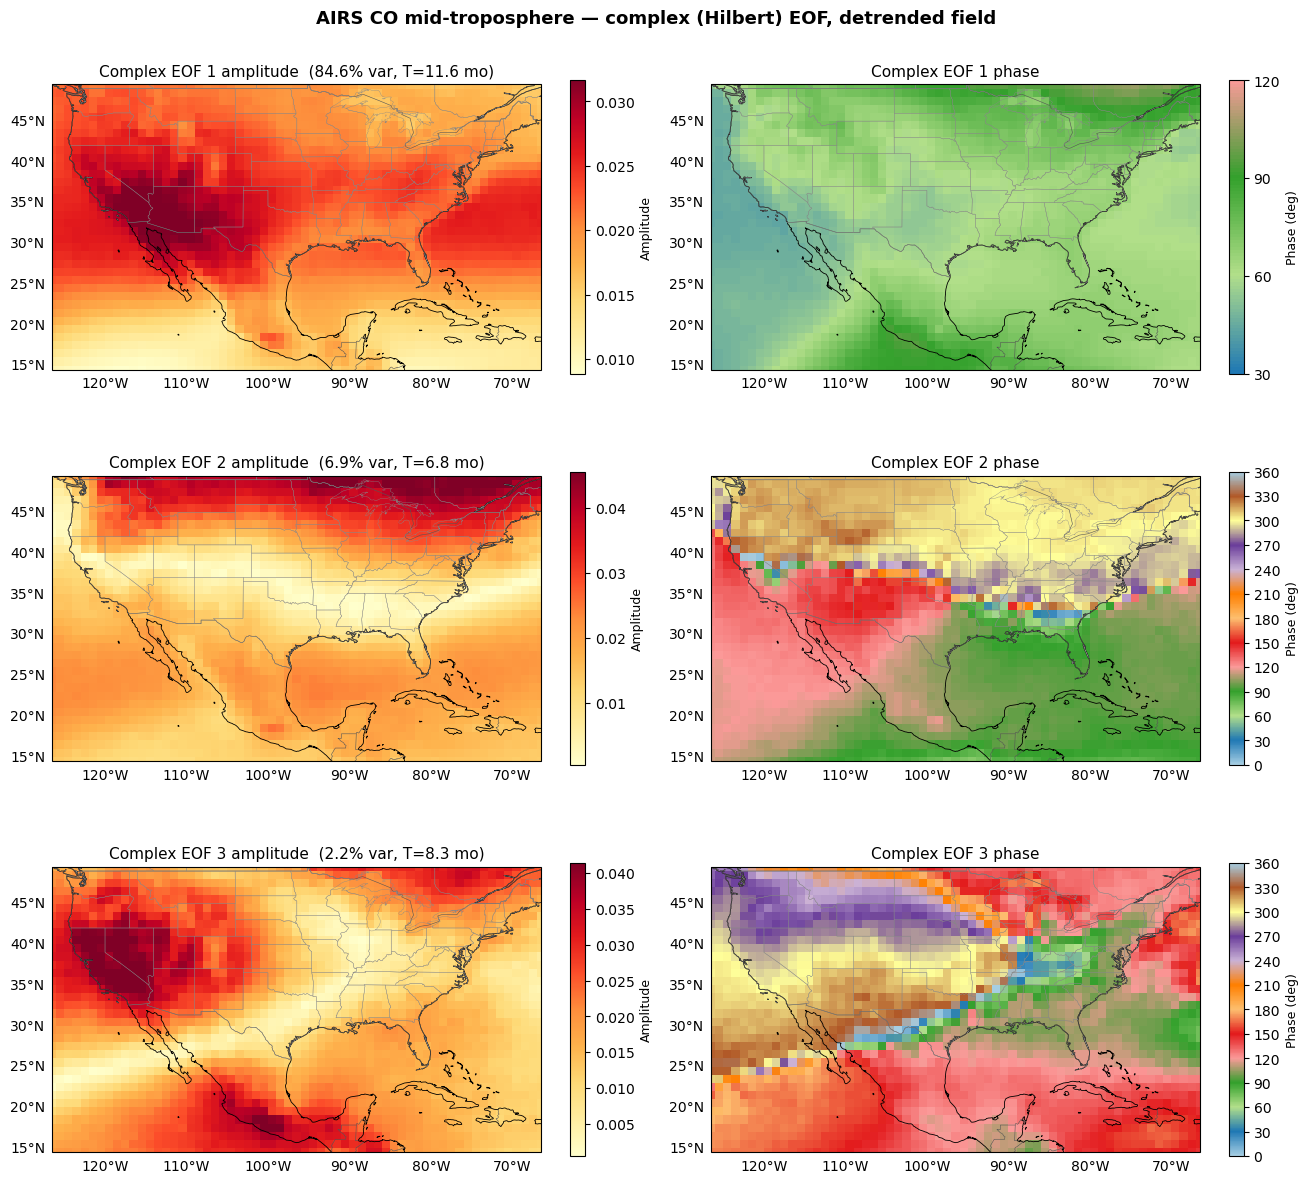

Saved -> ../Figures/no-coslat\ceof_amp_phase_2003_2025.png


In [9]:
import matplotlib.colors as mcolors
import itertools

lons = detr_field["lon"].values
lats = detr_field["lat"].values

ext = [float(lons.min()), float(lons.max()),
       float(lats.min()), float(lats.max())]


distinct_colors = plt.get_cmap("Paired").colors   # exactly 12 distinct colors, one per 30-deg bin

def build_fixed_phase_cmap():
    bin_starts = np.arange(0, 360, 30)                      # 0,30,...,330 (12 anchors)
    n_bins = len(bin_starts)                                 # = 12, matches len(distinct_colors) exactly
    bin_colors = list(itertools.islice(itertools.cycle(distinct_colors), n_bins))
    anchor_colors = bin_colors + [bin_colors[0]]             # force color(360) == color(0)
    cmap = mcolors.LinearSegmentedColormap.from_list("phase_fixed", anchor_colors, N=360)
    norm = mcolors.Normalize(vmin=0, vmax=360)
    return cmap, norm

phase_cmap, phase_norm = build_fixed_phase_cmap()

def circular_range(deg_vals):
    """Smallest contiguous window (mod 360) containing all finite values, found
    by locating the single largest empty gap on the circle."""
    v = np.sort(np.mod(deg_vals[np.isfinite(deg_vals)], 360))
    if v.size == 0:
        return 0.0, 360.0, False
    gaps = np.diff(np.concatenate([v, [v[0] + 360]]))
    k = np.argmax(gaps)
    start = v[(k + 1) % v.size]
    end = start + (360 - gaps[k])
    return float(start), float(end), end > 360

def crop_to_30deg(lo, hi):
    """Round the display window out to the nearest enclosing multiples of 30,
    so the colorbar never starts or ends mid-bin."""
    return float(np.floor(lo / 30) * 30), float(np.ceil(hi / 30) * 30)

def ceof_map(ax, data, cmap, label, title, vmin=None, vmax=None, norm=None):
    ax.set_extent(ext, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
    ax.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")
    pcm = ax.pcolormesh(lons, lats, data, transform=ccrs.PlateCarree(),
                        cmap=cmap, vmin=vmin, vmax=vmax, norm=norm, shading="nearest")
    gl = ax.gridlines(draw_labels=True, linewidth=0, color="none")
    gl.top_labels = gl.right_labels = False
    cb = fig_ca.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)
    cb.set_label(label, fontsize=9)
    ax.set_title(title, fontsize=11, pad=6)
    return cb

n_show = 3
fig_ca, axes_ca = plt.subplots(
    n_show, 2, figsize=(13, 4 * n_show),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True,
)

for i in range(n_show):
    mode_k = i + 1
    amp_i = ceof_amp.sel(mode=mode_k).values
    pha_i = np.rad2deg(ceof_pha.sel(mode=mode_k).values) % 360  # -> 0..360

    ceof_map(axes_ca[i, 0], amp_i, "YlOrRd", "Amplitude",
             f"Complex EOF {mode_k} amplitude  ({cexpvar[i]:.1f}% var, "
             f"T={mode_periods[mode_k]:.1f} mo)",
             vmax=np.nanpercentile(amp_i, 98))

    # phase: fixed global colormap/norm (same color = same angle everywhere),
    # colorbar cropped to the actual data range, rounded out to multiples of 30
    start, end, wraps = circular_range(pha_i)
    cb = ceof_map(axes_ca[i, 1], pha_i, phase_cmap, "Phase (deg)",
                  f"Complex EOF {mode_k} phase", norm=phase_norm)

    if not wraps:
        lo30, hi30 = crop_to_30deg(start, end)
        cb.ax.set_ylim(lo30, hi30)
        ticks = np.arange(lo30, hi30 + 1e-6, 30)
    else:
        # data straddle the 0/360 seam -- a single linear crop can't represent
        # that on one colorbar axis, so show the full cyclic bar for this mode
        ticks = np.arange(0, 361, 30)
        print(f"Mode {mode_k}: phase wraps the 0/360 seam -> showing full colorbar")
    cb.set_ticks(ticks)

fig_ca.suptitle("AIRS CO mid-troposphere — complex (Hilbert) EOF, detrended field",
                fontsize=13, fontweight="bold")
out_ca = os.path.join(OUT_DIR, "ceof_amp_phase_2003_2025.png")
fig_ca.savefig(out_ca, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_ca)

**Plot: the complex PCs.** Real and imaginary parts are shown together (the same signal a
quarter cycle apart), with the amplitude envelope on top — the envelope shows which years
the mode was strong.

In [10]:
import pandas as pd

# Pull the time axis straight from the fitted data so it's guaranteed to line up
# element-for-element with cpcs. Handles both datetime64 and cftime-style coords.
time_raw = cpcs["time"].values

try:
    months = pd.to_datetime(time_raw)
except Exception:
    # Fallback: cftime objects (common with decode_timedelta=False) don't always
    # convert cleanly through pandas -- go via ISO strings instead.
    months = pd.to_datetime([t.isoformat() for t in time_raw])

print(f"months: {months[0]} to {months[-1]}  (n = {len(months)})")

months: 2003-01-01 00:00:00 to 2025-12-01 00:00:00  (n = 276)


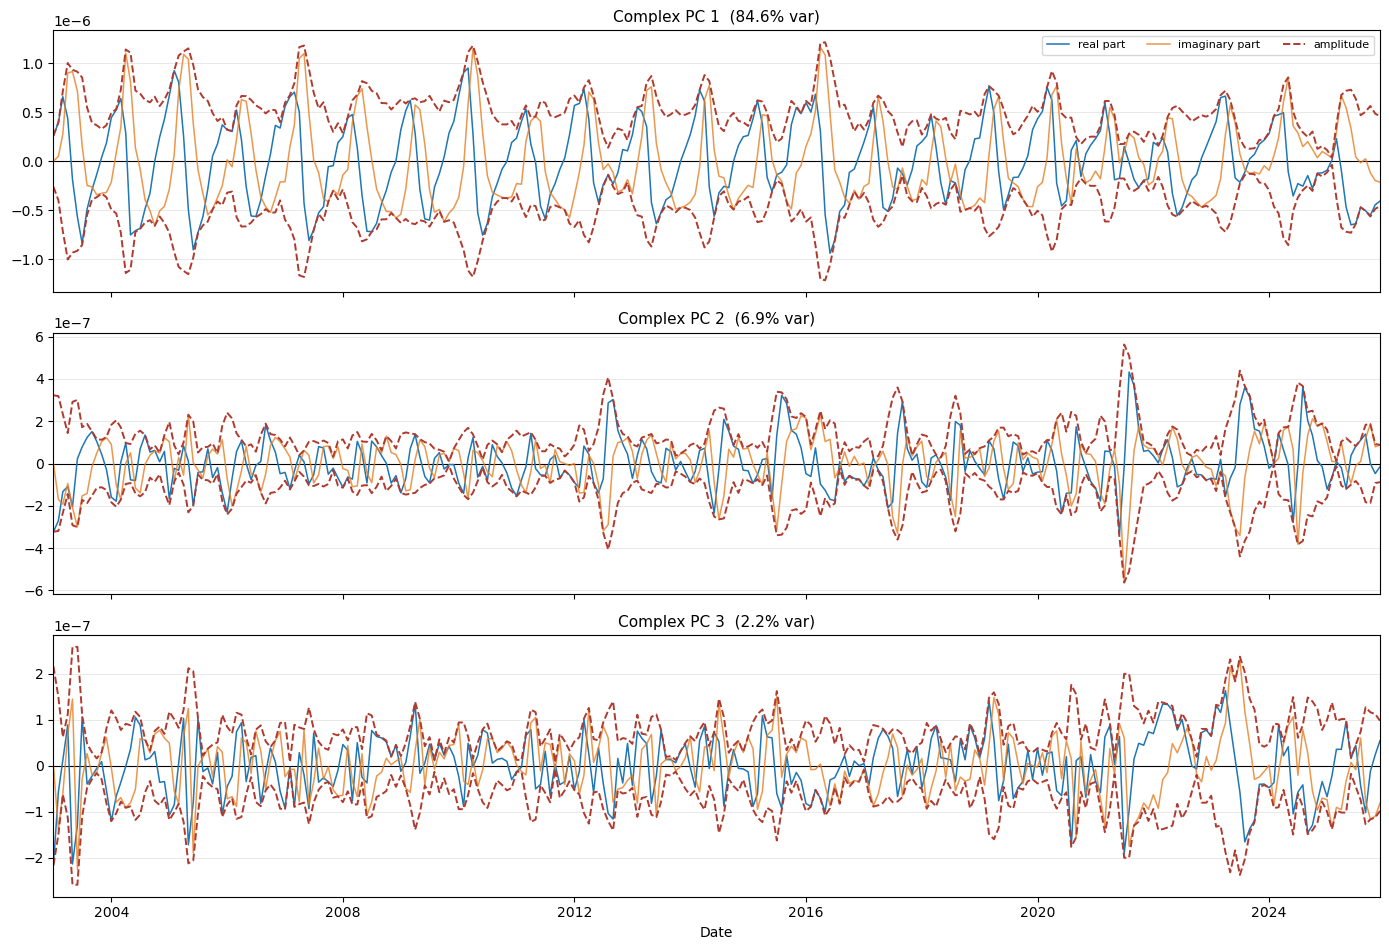

Saved -> ../Figures/no-coslat\ceof_pcs_2003_2025.png


In [11]:
# First 3 complex PCs: real & imaginary parts, plus the amplitude envelope.
fig_cp, axes_cp = plt.subplots(n_show, 1, figsize=(14, 3.2 * n_show), sharex=True)

for i in range(n_show):
    ax = axes_cp[i]
    pc_i = cpcs.sel(mode=i+1).values      # complex

    # Envelope taken from the PC itself, so it is on the same scale as the parts.
    env = np.abs(pc_i)

    ax.axhline(0, color="k", lw=0.8)
    ax.plot(months, pc_i.real, lw=1.1, color="#1f77b4", label="real part")
    ax.plot(months, pc_i.imag, lw=1.1, color="#e67e22", alpha=0.8, label="imaginary part")
    ax.plot(months, env,  lw=1.4, color="#b03a2e", ls="--", label="amplitude")
    ax.plot(months, -env, lw=1.4, color="#b03a2e", ls="--")

    ax.set_title(f"Complex PC {i+1}  ({cexpvar[i]:.1f}% var)", fontsize=11)
    ax.grid(axis="y", lw=0.4, alpha=0.5)
    if i == 0:
        ax.legend(fontsize=8, loc="upper right", ncol=3)

axes_cp[-1].set_xlabel("Date")
axes_cp[-1].set_xlim(months[0], months[-1])

fig_cp.tight_layout()
out_cp = os.path.join(OUT_DIR, "ceof_pcs_2003_2025.png")
fig_cp.savefig(out_cp, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_cp)

**Do the complex-mode variances also add to 100%?** Same check as for the real EOF.

In [12]:
# Refit with every possible mode and sum the percentage variances.
n_time_c = detr_field.sizes["time"]

cmodel_all = HilbertEOF(n_modes=n_time_c, use_coslat=False, padding="exp",
                        decay_factor=0.2, solver="full")
cmodel_all.fit(detr_field, dim="time")
cexpvar_all = cmodel_all.explained_variance_ratio().values * 100

print(f"Modes returned              : {len(cexpvar_all)}")
print(f"Sum of percentage variances : {cexpvar_all.sum():.6f} %")
print(f"Equal to 100%? {np.isclose(cexpvar_all.sum(), 100.0)}")

Modes returned              : 276
Sum of percentage variances : 100.000000 %
Equal to 100%? True


## Relative phase and reconstruction over reference boxes

In [13]:
BOXES = {
    1: dict(LAT0=31, LAT1=36, LON0=-117, LON1=-112),
    2: dict(LAT0=45, LAT1=49, LON0=-85,  LON1=-70),
    3: dict(LAT0=17, LAT1=19, LON0=-102, LON1=-99),
    # -100.861927,18.016450,-97.671920,20.439904
}

ref_ceof   = {}     # complex box reference per mode
recon_ceof = {}     # conjugate reconstruction over box per mode

def box_mean(da, MODE_K):
    b = BOXES[MODE_K]
    return da.sel(lat=slice(b["LAT0"], b["LAT1"]), lon=slice(b["LON0"], b["LON1"])).mean(("lat", "lon"))

def quarter_ticks(months):
    quarter_mask = months.month.isin([1, 4, 7, 10])
    tick_dates = months[quarter_mask]

    labels = []
    for d in tick_dates:
        letter = d.strftime("%b")[0]          # J, A, J, O
        if d.month == 1:
            labels.append(f"{letter}\n{d.year}")
        else:
            labels.append(letter)
    return tick_dates, labels

def build_relphase_cmap(relphase_colors_12):
    anchor_colors = relphase_colors_12 + [relphase_colors_12[0]]   # force color(360) == color(0)
    cmap = mcolors.LinearSegmentedColormap.from_list("relphase", anchor_colors, N=360)
    norm = mcolors.Normalize(vmin=0, vmax=360)
    return cmap, norm


# ============================================================
# Relative phase for a single mode, referenced to a lat/lon box
# ============================================================
def plot_relphase(MODE_K, relphase_colors_12):
    LAT0, LAT1, LON0, LON1 = (BOXES[MODE_K][k] for k in ("LAT0", "LAT1", "LON0", "LON1"))

    comp_k = ceofs.sel(mode=MODE_K)                       # complex, (lat, lon)
    amp_k  = ceof_amp.sel(mode=MODE_K).values

    # --- complex mean over the box
    box = comp_k.sel(lat=slice(LAT0, LAT1), lon=slice(LON0, LON1))
    ref = box.mean(("lat", "lon"))

    coherence = float(np.abs(ref) / np.abs(box).mean())
    print(f"Mode {MODE_K}: box coherence = {coherence:.6f}"
          + ("  (low -- consider a smaller/more uniform box)" if coherence < 0.8 else ""))

    # --- relative phase: multiply by conjugate of the (unit-modulus) reference ---
    rel_phase = np.rad2deg(np.angle(comp_k * np.conj(ref) / np.abs(ref))) % 360   # -> 0..360

    relphase_cmap, relphase_norm = build_relphase_cmap(relphase_colors_12)

    # ============================================================
    # Plot: amplitude (left) + relative phase (right), single mode
    # ============================================================
    fig_rp, axes_rp = plt.subplots(
        1, 2, figsize=(13, 4.5),
        subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True,
    )

    ceof_map(axes_rp[0], amp_k, "YlOrRd", "Amplitude",
             f"Complex EOF {MODE_K} amplitude  ({cexpvar[MODE_K-1]:.1f}% var, "
             f"T={mode_periods[MODE_K]:.1f} mo)",
             vmax=np.nanpercentile(amp_k, 98))

    ax_pha = axes_rp[1]
    ax_pha.set_extent(ext, crs=ccrs.PlateCarree())
    ax_pha.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
    ax_pha.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
    ax_pha.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")
    ax_pha.pcolormesh(lons, lats, rel_phase, transform=ccrs.PlateCarree(),
                      cmap=relphase_cmap, norm=relphase_norm, shading="nearest")
    gl = ax_pha.gridlines(draw_labels=True, linewidth=0, color="none")
    gl.top_labels = gl.right_labels = False
    ax_pha.set_title(f"Complex EOF {MODE_K} relative phase",
                      fontsize=11, pad=6)

    # --- colorbar: seam-centered (0/360 in the middle), cropped to the data's actual range ---
    # doubled version of THIS plot's colormap, spanning -360..360, so a window straddling
    # the seam always has real color to draw from (a plain Normalize(0,360) colorbar renders
    # blank past its own ends)
    double_colors = [relphase_cmap(relphase_norm(v % 360)) for v in np.linspace(-360, 360, 721)]
    double_cmap = mcolors.ListedColormap(double_colors)
    double_norm = mcolors.Normalize(vmin=-360, vmax=360)

    sm = plt.cm.ScalarMappable(cmap=double_cmap, norm=double_norm)
    cb = fig_rp.colorbar(sm, ax=ax_pha, orientation="vertical", fraction=0.03, pad=0.06)
    cb.set_label("Phase relative to box (deg)", fontsize=9)

    rel_phase_shifted = ((rel_phase + 180) % 360) - 180
    lo = np.floor(np.nanmin(rel_phase_shifted) / 30) * 30
    hi = np.ceil(np.nanmax(rel_phase_shifted) / 30) * 30

    cb.ax.set_ylim(lo, hi)
    ticks_shifted = np.arange(lo, hi + 1e-6, 30)
    cb.set_ticks(ticks_shifted)
    cb.set_ticklabels([f"{int(t % 360)}" for t in ticks_shifted])

    print(f"Mode {MODE_K}: relative phase colorbar window "
          f"[{lo % 360:.0f}° .. {hi % 360 if hi != 180 else 360:.0f}°], centered on 0/360")

    for ax in axes_rp:
        ax.plot([LON0, LON1, LON1, LON0, LON0], [LAT0, LAT0, LAT1, LAT1, LAT0],
                "k-", lw=1.8, transform=ccrs.PlateCarree())

    fig_rp.suptitle("AIRS CO mid-troposphere — relative phase vs. reference box",
                    fontsize=13, fontweight="bold")
    out_rp = os.path.join(OUT_DIR, f"ceof_relphase_mode{MODE_K}_2003_2025.png")
    fig_rp.savefig(out_rp, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ->", out_rp)

    ref_ceof[MODE_K] = ref
    return ref


def plot_recon_conj(MODE_K):
    score_k = cpcs.sel(mode=MODE_K)                        # complex, (time,)

    # --- reconstruction with conjugating ref: score(t) * conj(ref) ---
    recon_conj = (score_k * np.conj(ref_ceof[MODE_K])).real

    fig2, ax2 = plt.subplots(figsize=(13, 3.5))
    ax2.plot(months, recon_conj.values, lw=1.2, color="#1f77b4")
    ax2.axhline(0, color="k", lw=0.6)
    ax2.set_title(f"Mode {MODE_K} reconstruction over box")
    ax2.set_ylabel("Reconstructed CO detrended field")

    tick_dates, labels = quarter_ticks(months)
    ax2.set_xticks(tick_dates)
    ax2.grid(axis="x", which="major", lw=0.4, alpha=0.5)

    # thicker tick marks and gridlines at January (year boundaries)
    for tick_date, tick in zip(tick_dates, ax2.xaxis.get_major_ticks()):
        if tick_date.month == 1:
            tick.tick1line.set_markersize(7)
            tick.gridline.set_linewidth(1.2)
            tick.gridline.set_alpha(0.8)

    ax2.set_xticklabels(labels, fontsize=7, rotation=0)
    ax2.set_xlim(months[0], months[-1])
    plt.tight_layout()
    out_conj = os.path.join(OUT_DIR, f"ceof_recon_mode{MODE_K}_box_conj.png")
    fig2.savefig(out_conj, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ->", out_conj)

    recon_ceof[MODE_K] = recon_conj
    return recon_conj

### Mode 1

Mode 1: box coherence = 0.999333
Mode 1: relative phase colorbar window [330° .. 60°], centered on 0/360


C:\Users\ACER\AppData\Local\Temp\ipykernel_30884\860225239.py:50: UserWarning: Adding colorbar to a different Figure <Figure size 1300x450 with 3 Axes> than <Figure size 1300x1200 with 12 Axes> which fig.colorbar is called on.
  cb = fig_ca.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)


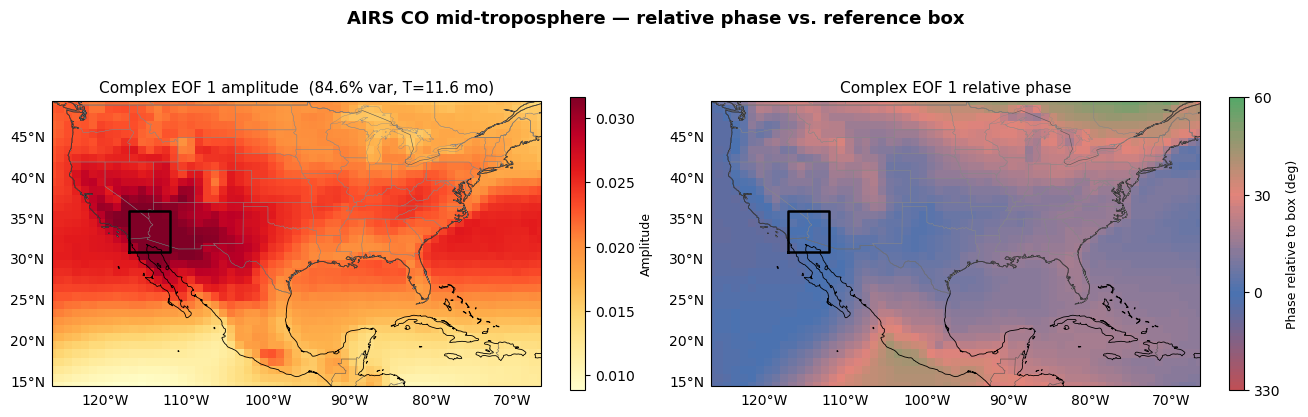

Saved -> ../Figures/no-coslat\ceof_relphase_mode1_2003_2025.png


In [14]:
relphase_colors_mode1 = [
    "#4b72b0",  # [0]  Soft Slate Blue (Start)
    "#e2847a",  # [1]  Soft Coral Red
    "#55a868",  # [2]  Muted Sage Green
    "#dd8452",  # [3]  Muted Apricot Orange
    "#8172b3",  # [4]  Soft Lavender Purple
    "#ccb974",  # [5]  Muted Olive / Sand
    "#64b5cd",  # [6]  Soft Sky Cyan
    "#59a14f",  # [8]  Soft Leaf Green
    "#b07aa1",  # [9]  Soft Orchid Pink
    "#2f4b7c",  # [10] Muted Deep Indigo
    "#e09f53",  # [11] Warm Ochre / Amber (high contrast with both [10] and [0])
    "#c44e52",
]

plot_relphase(1, relphase_colors_mode1);

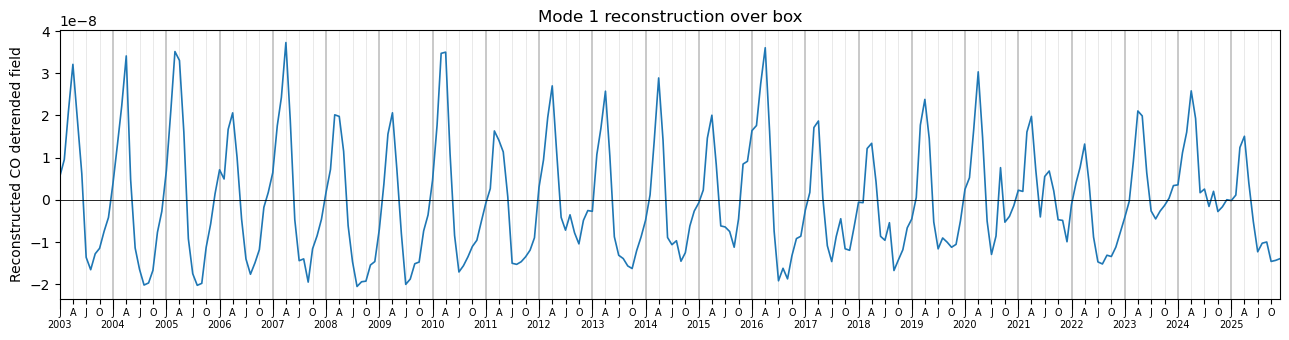

Saved -> ../Figures/no-coslat\ceof_recon_mode1_box_conj.png


In [15]:
plot_recon_conj(1);

### Mode 2

Mode 2: box coherence = 0.999787
Mode 2: relative phase colorbar window [180° .. 360°], centered on 0/360


C:\Users\ACER\AppData\Local\Temp\ipykernel_30884\860225239.py:50: UserWarning: Adding colorbar to a different Figure <Figure size 1300x450 with 3 Axes> than <Figure size 1300x1200 with 12 Axes> which fig.colorbar is called on.
  cb = fig_ca.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)


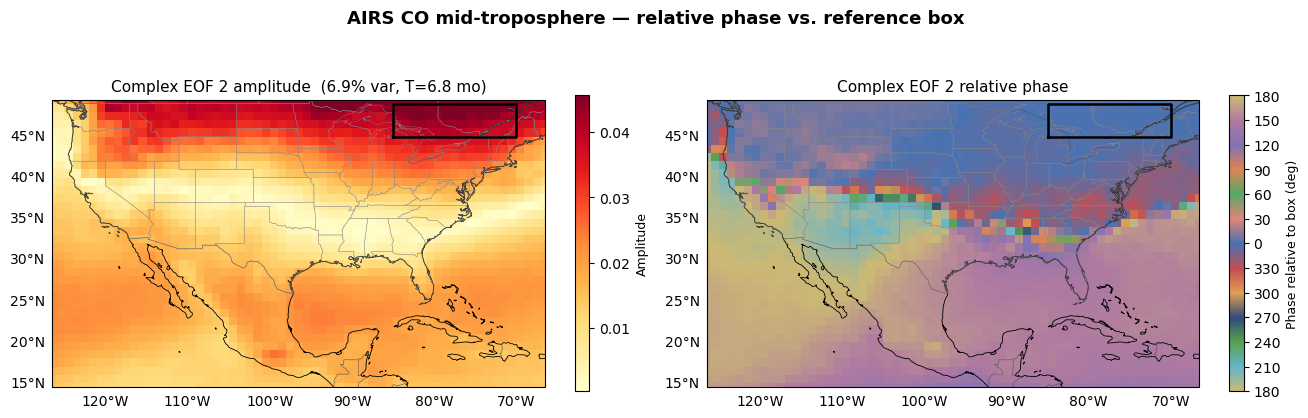

Saved -> ../Figures/no-coslat\ceof_relphase_mode2_2003_2025.png


In [16]:
relphase_colors_mode23 = [
    "#4b72b0",  # [0]  Soft Slate Blue (Start)
    "#e2847a",  # [1]  Soft Coral Red
    "#55a868",  # [2]  Muted Sage Green
    "#dd8452",  # [3]  Muted Apricot Orange
    "#8172b3",
    "#b07aa1",  # [4]  Soft Lavender Purple
    "#ccb974",  # [5]  Muted Olive / Sand
    "#64b5cd",  # [6]  Soft Sky Cyan
    "#59a14f",  # [8]  Soft Leaf Green
    "#2f4b7c",  # [10] Muted Deep Indigo
    "#e09f53",  # [11] Warm Ochre / Amber (high contrast with both [10] and [0])
    "#c44e52",
]

plot_relphase(2, relphase_colors_mode23);

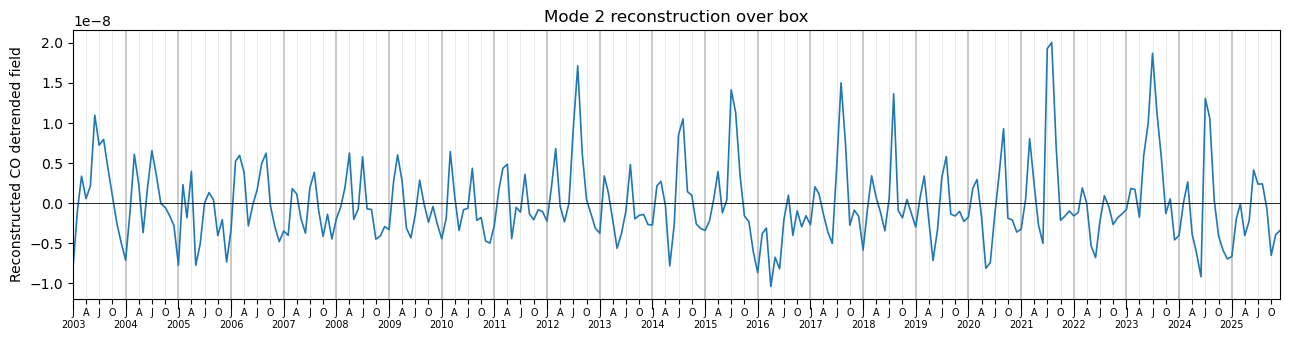

Saved -> ../Figures/no-coslat\ceof_recon_mode2_box_conj.png


In [17]:
plot_recon_conj(2);

### Mode 3

Mode 3: box coherence = 0.995514
Mode 3: relative phase colorbar window [180° .. 360°], centered on 0/360


C:\Users\ACER\AppData\Local\Temp\ipykernel_30884\860225239.py:50: UserWarning: Adding colorbar to a different Figure <Figure size 1300x450 with 3 Axes> than <Figure size 1300x1200 with 12 Axes> which fig.colorbar is called on.
  cb = fig_ca.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)


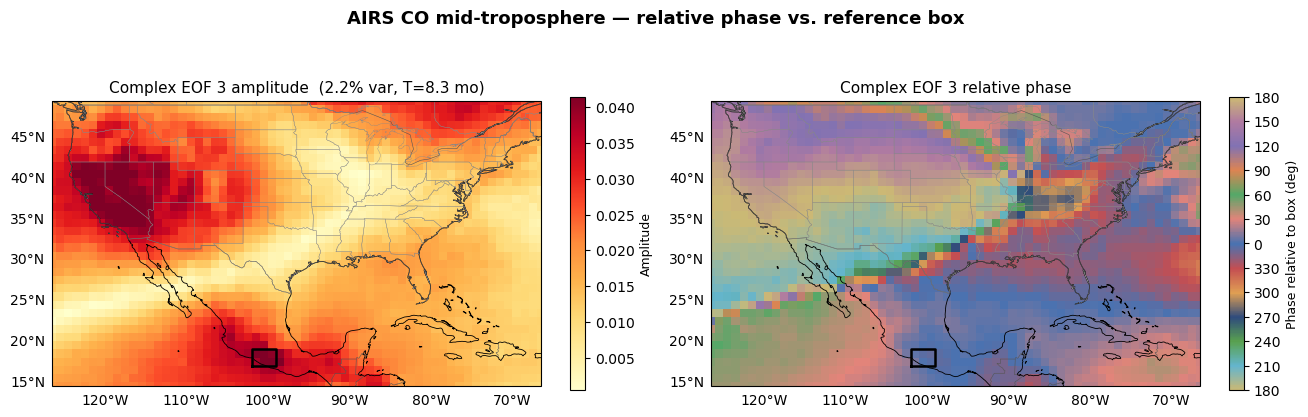

Saved -> ../Figures/no-coslat\ceof_relphase_mode3_2003_2025.png


In [18]:
relphase_colors_mode23 = [
    "#4b72b0",  # [0]  Soft Slate Blue (Start)
    "#e2847a",  # [1]  Soft Coral Red
    "#55a868",  # [2]  Muted Sage Green
    "#dd8452",  # [3]  Muted Apricot Orange
    "#8172b3",
    "#b07aa1",  # [4]  Soft Lavender Purple
    "#ccb974",  # [5]  Muted Olive / Sand
    "#64b5cd",  # [6]  Soft Sky Cyan
    "#59a14f",  # [8]  Soft Leaf Green
    "#2f4b7c",  # [10] Muted Deep Indigo
    "#e09f53",  # [11] Warm Ochre / Amber (high contrast with both [10] and [0])
    "#c44e52",
]

plot_relphase(3, relphase_colors_mode23);


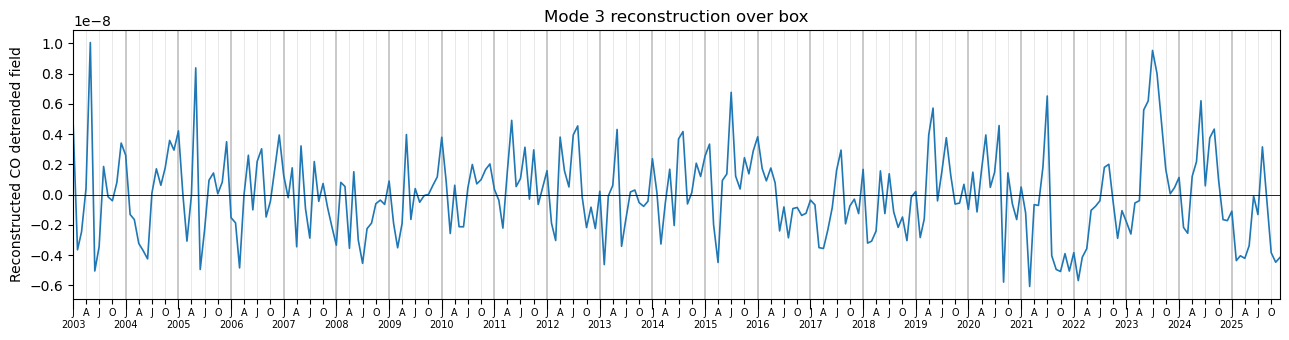

Saved -> ../Figures/no-coslat\ceof_recon_mode3_box_conj.png


In [19]:
plot_recon_conj(3);

## Reconstructions: normal EOF vs complex EOF

In [20]:
recon_eof = {}      # normal EOF reconstruction over box per mode

def plot_eof_vs_ceof(MODE_K):
    # --- reconstruction from the normal (real) EOF, same box ---
    recon_field_eof = (eofs.sel(mode=MODE_K) * pcs.sel(mode=MODE_K))
    recon_eof[MODE_K] = box_mean(recon_field_eof, MODE_K)

    fig4, ax4 = plt.subplots(figsize=(13, 3.5))
    ax4.plot(months, recon_ceof[MODE_K].values, lw=1.2, color="#1f77b4", label=f"Complex EOF mode {MODE_K}")
    ax4.plot(months, recon_eof[MODE_K].values, lw=1.2, color="#ff7f0e", label=f"Normal EOF mode {MODE_K}")
    ax4.axhline(0, color="k", lw=0.6)
    ax4.set_title(f"Mode {MODE_K} reconstruction over box — complex vs. normal EOF")
    ax4.set_ylabel("Reconstructed CO detrended field")
    ax4.legend(fontsize=9, loc="upper right")

    tick_dates, labels = quarter_ticks(months)
    ax4.set_xticks(tick_dates)
    ax4.set_xticklabels(labels, fontsize=7, rotation=0)
    ax4.set_xlim(months[0], months[-1])
    plt.tight_layout()
    out_cmp = os.path.join(OUT_DIR, f"eof_vs_ceof_recon_mode{MODE_K}_box.png")
    fig4.savefig(out_cmp, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ->", out_cmp)


def plot_vs_detrended(MODE_K):
    # --- overlay the original detrended field's box-averaged time series ---
    detr_box_ts = box_mean(detr_field, MODE_K)

    fig5, ax5 = plt.subplots(figsize=(13, 3.5))
    ax5.plot(months, detr_box_ts.values, lw=1.0, color="#7f7f7f", alpha=0.7, label="Detrended field (original)")
    ax5.plot(months, recon_ceof[MODE_K].values, lw=1.2, color="#1f77b4", label=f"Complex EOF mode {MODE_K}")
    ax5.plot(months, recon_eof[MODE_K].values, lw=1.2, color="#ff7f0e", label=f"Normal EOF mode {MODE_K}")
    ax5.axhline(0, color="k", lw=0.6)
    ax5.set_title(f"Mode {MODE_K} reconstruction over box — vs. original detrended field")
    ax5.set_ylabel("CO detrended field")
    ax5.legend(fontsize=9, loc="upper right")

    tick_dates, labels = quarter_ticks(months)
    ax5.set_xticks(tick_dates)
    ax5.set_xticklabels(labels, fontsize=7, rotation=0)
    ax5.set_xlim(months[0], months[-1])
    plt.tight_layout()
    out_cmp2 = os.path.join(OUT_DIR, f"eof_vs_ceof_vs_detrended_mode{MODE_K}_box.png")
    fig5.savefig(out_cmp2, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ->", out_cmp2)

### Mode 1

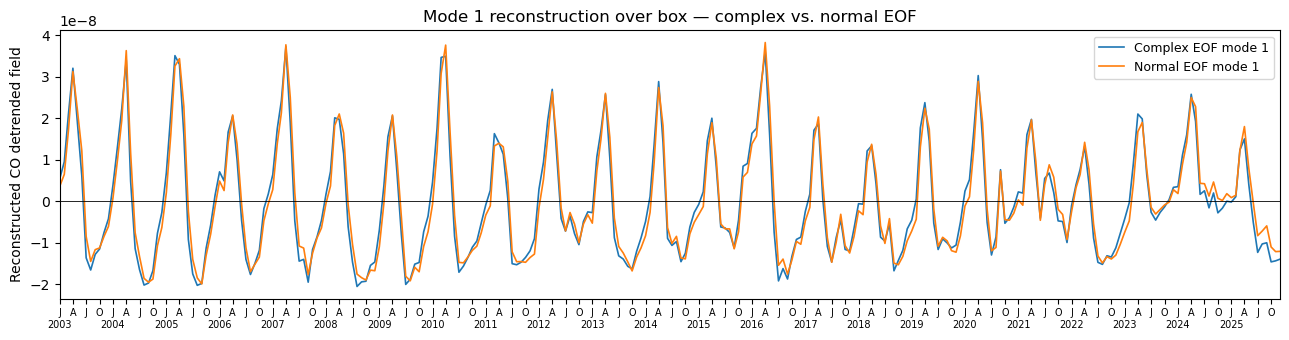

Saved -> ../Figures/no-coslat\eof_vs_ceof_recon_mode1_box.png


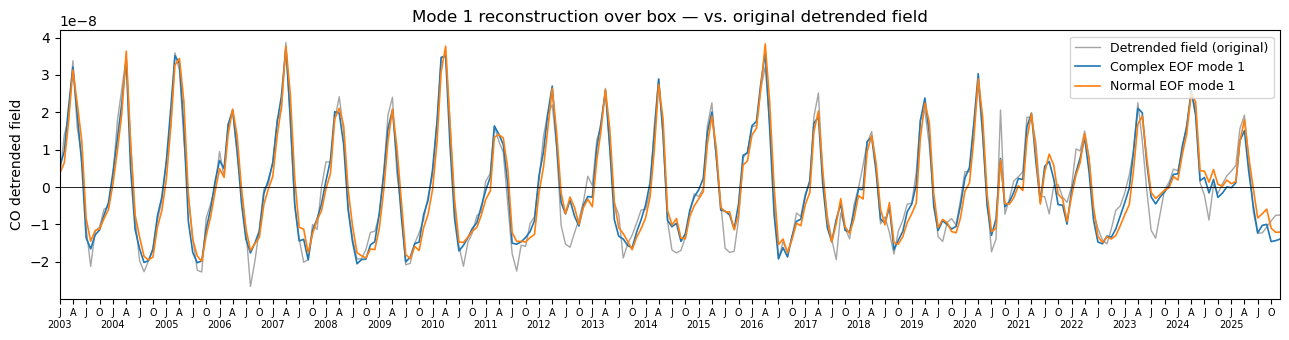

Saved -> ../Figures/no-coslat\eof_vs_ceof_vs_detrended_mode1_box.png


In [21]:
plot_eof_vs_ceof(1)
plot_vs_detrended(1)

### Mode 2

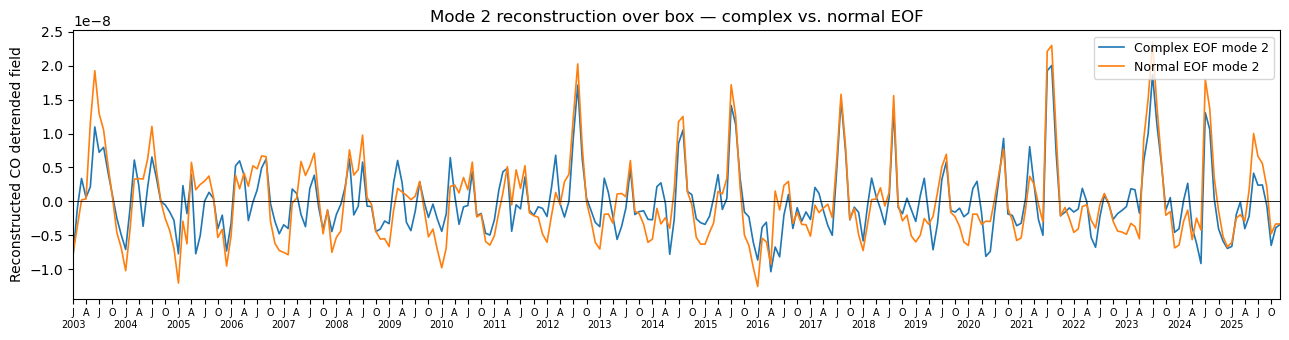

Saved -> ../Figures/no-coslat\eof_vs_ceof_recon_mode2_box.png


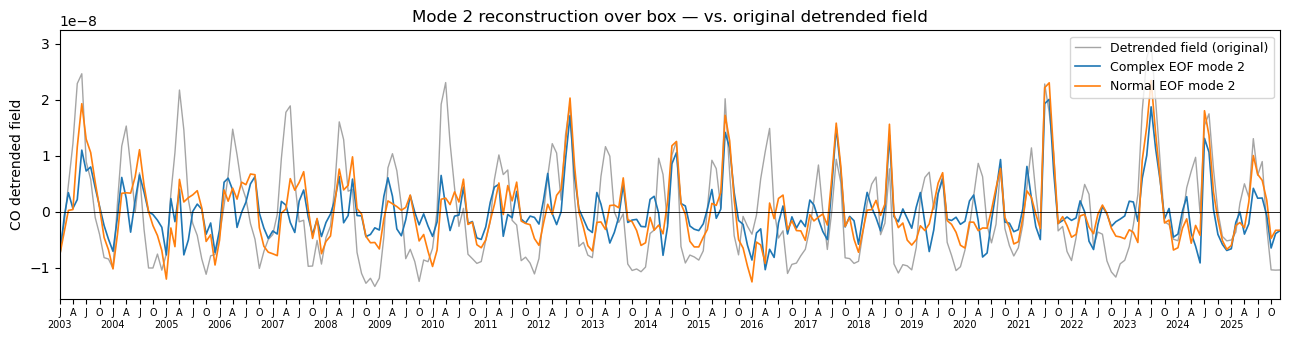

Saved -> ../Figures/no-coslat\eof_vs_ceof_vs_detrended_mode2_box.png


In [22]:
plot_eof_vs_ceof(2)
plot_vs_detrended(2)

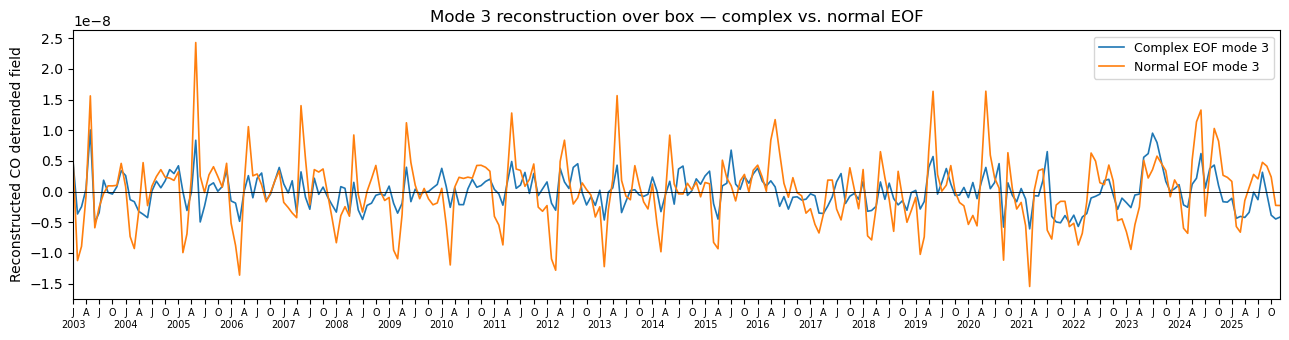

Saved -> ../Figures/no-coslat\eof_vs_ceof_recon_mode3_box.png


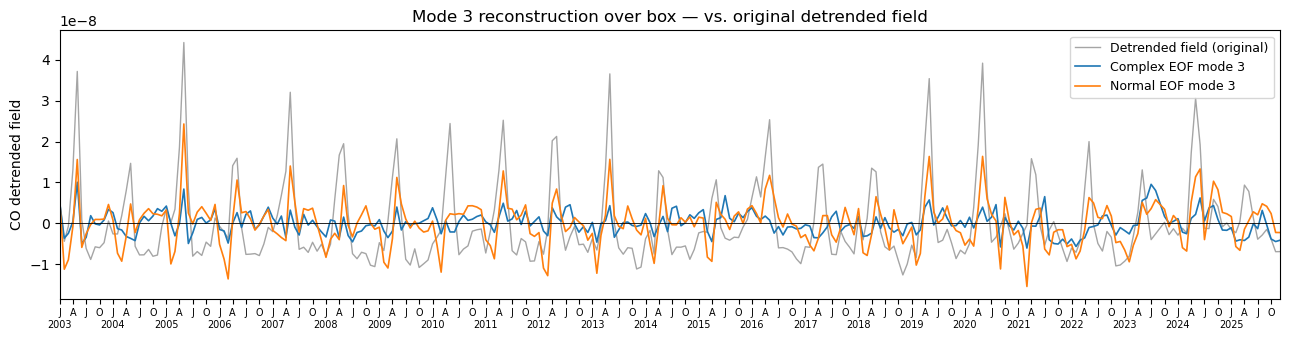

Saved -> ../Figures/no-coslat\eof_vs_ceof_vs_detrended_mode3_box.png


In [23]:
plot_eof_vs_ceof(3)
plot_vs_detrended(3)

## Detrended field vs modes 1, 2, 3

In [24]:
MODES_CMP = [1, 2, 3]
mode_colors = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}

def plot_modes_vs_detrended(kind, BOX_K=None):
    if BOX_K is None:
        area_mean = lambda da: da.mean(("lat", "lon"))
        where, tag = "whole domain", "domain"
    else:
        LAT0, LAT1, LON0, LON1 = (BOXES[BOX_K][k] for k in ("LAT0", "LAT1", "LON0", "LON1"))
        area_mean = lambda da: box_mean(da, BOX_K)
        where, tag = f"box {BOX_K} [{LAT0}-{LAT1}°N, {LON0}-{LON1}°E]", f"box{BOX_K}"

    detr_ts = area_mean(detr_field)

    fig6, ax6 = plt.subplots(figsize=(13, 3.5))
    ax6.plot(months, detr_ts.values, lw=1.0, color="#7f7f7f", alpha=0.7, label="Detrended field (original)")

    for k in MODES_CMP:
        if kind == "eof":
            recon_k = area_mean(eofs.sel(mode=k) * pcs.sel(mode=k))
            label = f"Normal EOF mode {k}"
        else:
            ref_k = area_mean(ceofs.sel(mode=k))
            recon_k = (cpcs.sel(mode=k) * np.conj(ref_k)).real
            label = f"Complex EOF mode {k}"
        ax6.plot(months, recon_k.values, lw=1.2, color=mode_colors[k], label=label)

    name = "Normal EOF" if kind == "eof" else "Complex EOF"
    ax6.axhline(0, color="k", lw=0.6)
    ax6.set_title(f"{name} modes 1-3 vs. original detrended field — {where}")
    ax6.set_ylabel("CO detrended field")
    ax6.legend(fontsize=9, loc="upper right")

    tick_dates, labels = quarter_ticks(months)
    ax6.set_xticks(tick_dates)
    ax6.set_xticklabels(labels, fontsize=7, rotation=0)
    ax6.set_xlim(months[0], months[-1])
    plt.tight_layout()
    out_modes = os.path.join(OUT_DIR, f"{kind}_modes123_vs_detrended_{tag}.png")
    fig6.savefig(out_modes, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ->", out_modes)

### Whole domain

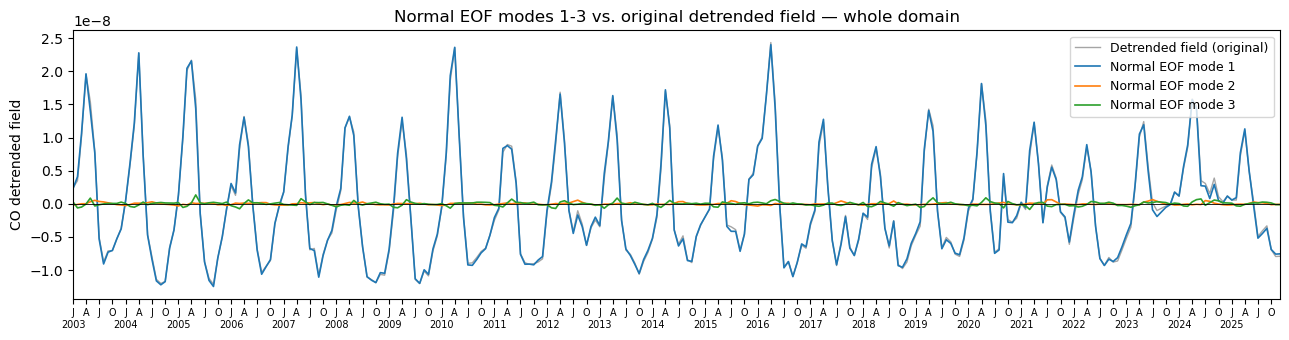

Saved -> ../Figures/no-coslat\eof_modes123_vs_detrended_domain.png


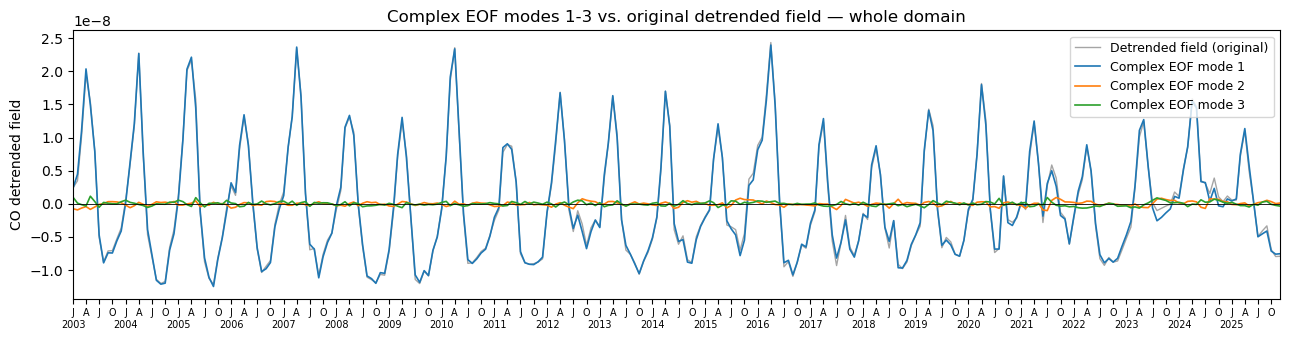

Saved -> ../Figures/no-coslat\ceof_modes123_vs_detrended_domain.png


In [25]:
plot_modes_vs_detrended("eof")
plot_modes_vs_detrended("ceof")

### Box 1

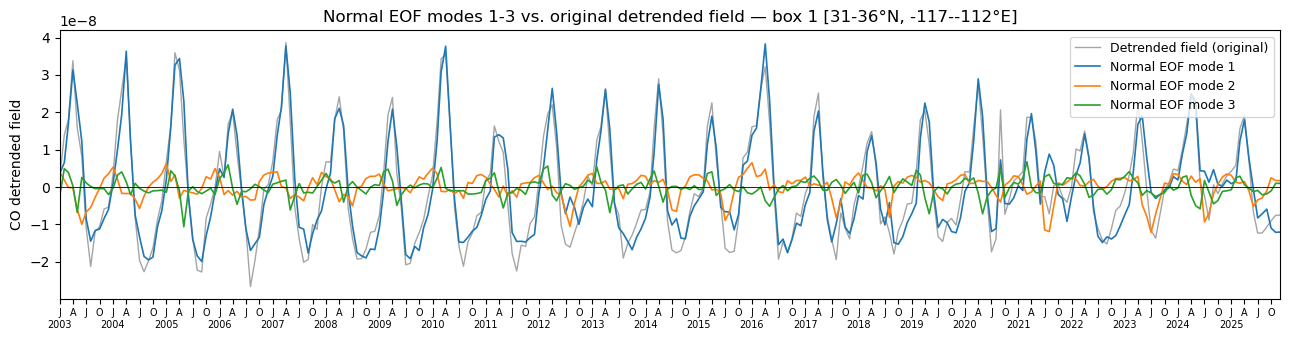

Saved -> ../Figures/no-coslat\eof_modes123_vs_detrended_box1.png


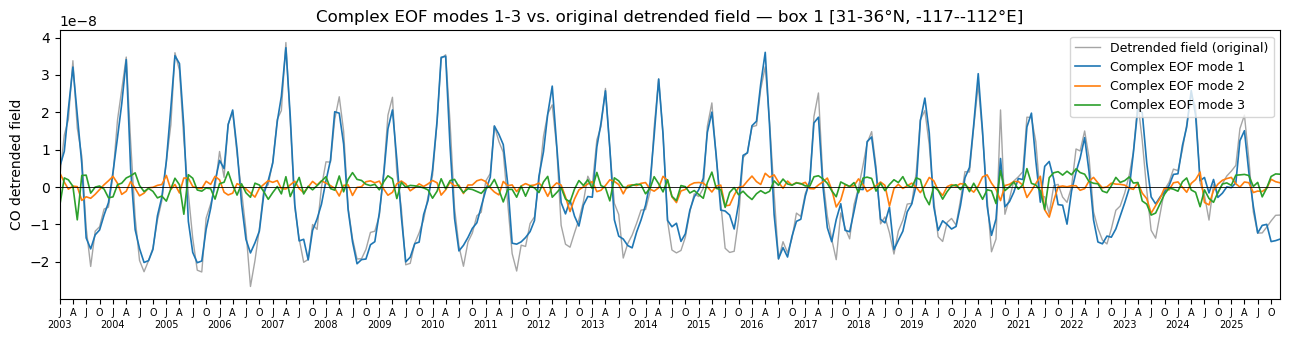

Saved -> ../Figures/no-coslat\ceof_modes123_vs_detrended_box1.png


In [26]:
plot_modes_vs_detrended("eof", BOX_K=1)
plot_modes_vs_detrended("ceof", BOX_K=1)

### Box 2

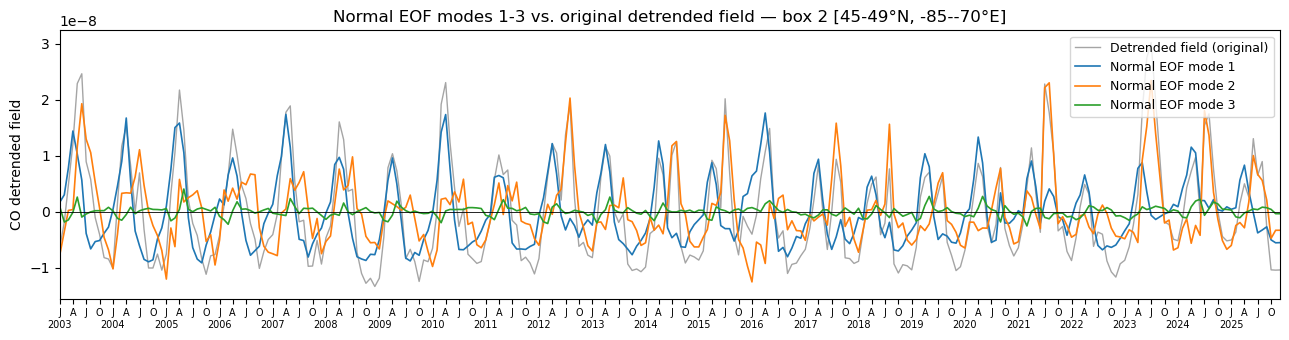

Saved -> ../Figures/no-coslat\eof_modes123_vs_detrended_box2.png


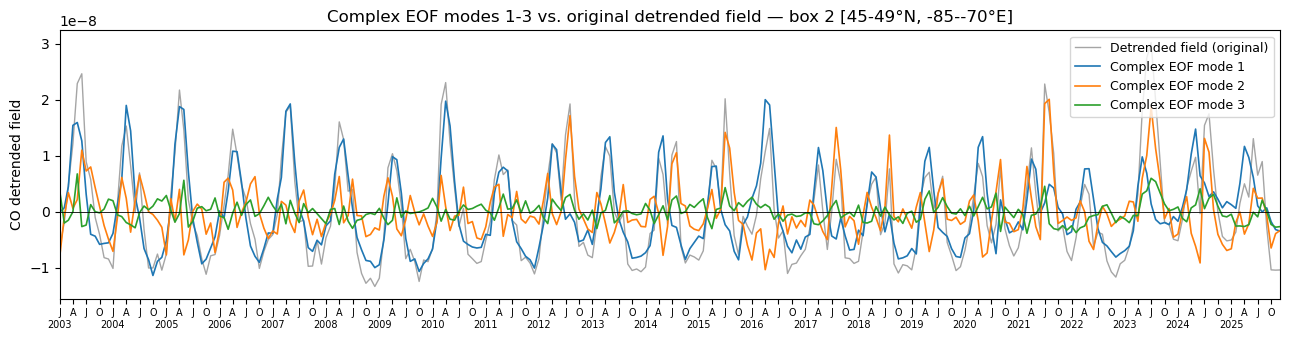

Saved -> ../Figures/no-coslat\ceof_modes123_vs_detrended_box2.png


In [27]:
plot_modes_vs_detrended("eof", BOX_K=2)
plot_modes_vs_detrended("ceof", BOX_K=2)

### Box 3

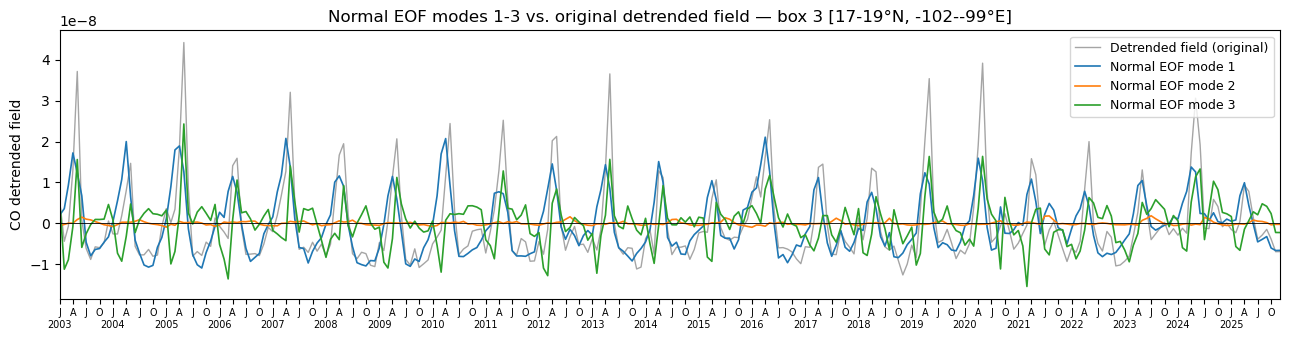

Saved -> ../Figures/no-coslat\eof_modes123_vs_detrended_box3.png


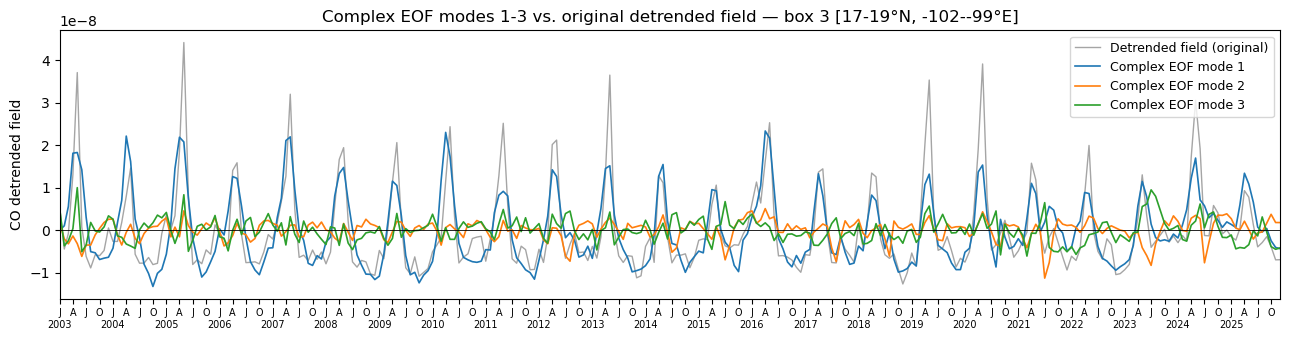

Saved -> ../Figures/no-coslat\ceof_modes123_vs_detrended_box3.png


In [28]:
plot_modes_vs_detrended("eof", BOX_K=3)
plot_modes_vs_detrended("ceof", BOX_K=3)

## Correlation (r): detrended field vs modes 1, 2, 3 in each box

In [29]:
rows = []
for BOX_K in BOXES:
    detr_ts = box_mean(detr_field, BOX_K).to_series()
    row = {"box": BOX_K}
    for kind in ("eof", "ceof"):
        for k in MODES_CMP:
            if kind == "eof":
                recon_k = box_mean(eofs.sel(mode=k) * pcs.sel(mode=k), BOX_K)
            else:
                ref_k = box_mean(ceofs.sel(mode=k), BOX_K)
                recon_k = (cpcs.sel(mode=k) * np.conj(ref_k)).real
            name = "EOF" if kind == "eof" else "CEOF"
            row[f"{name} {k}"] = detr_ts.corr(recon_k.to_series())
    rows.append(row)

corr_table = pd.DataFrame(rows).set_index("box")
corr_table.round(3)

,EOF 1,EOF 2,EOF 3,CEOF 1,CEOF 2,CEOF 3
box,,,,,,
1,0.946,0.227,0.172,0.966,0.140,0.173
2,0.685,0.689,0.103,0.788,0.541,0.208
3,0.743,0.049,0.563,0.837,0.245,0.277


## r² maps: detrended field vs mode index time series

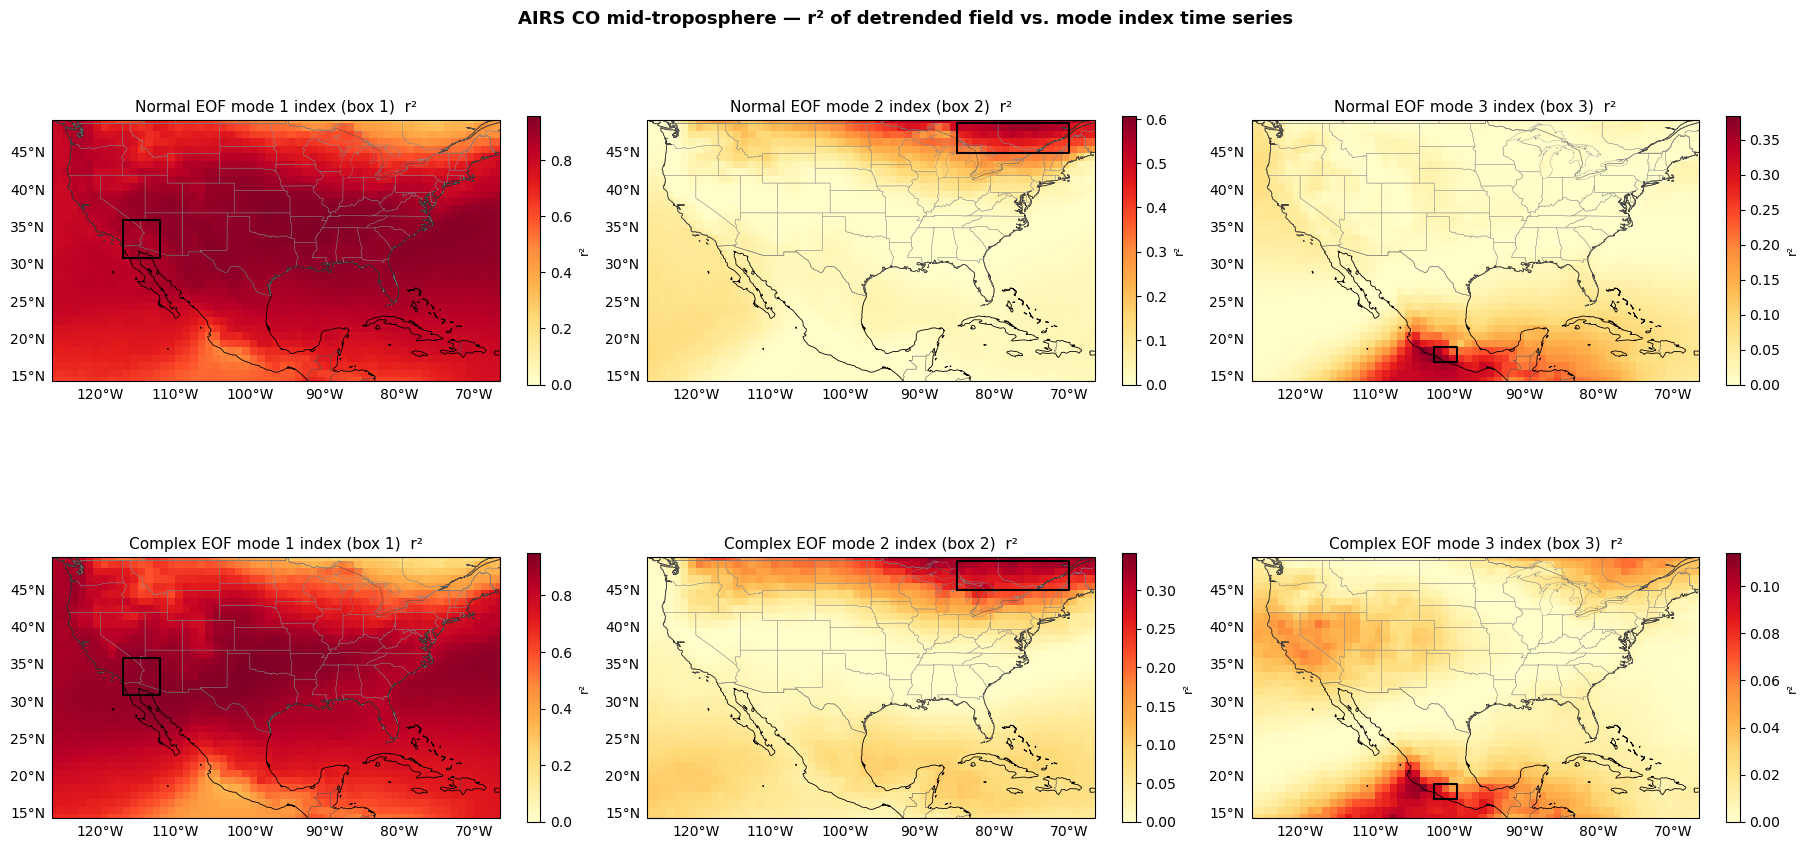

Saved -> ../Figures/no-coslat\r2_maps_index_eof_ceof_modes123.png


In [30]:
r2_maps = {"eof": {}, "ceof": {}}
for k in MODES_CMP:
    idx_eof_k  = box_mean(eofs.sel(mode=k) * pcs.sel(mode=k), k)
    ref_k      = box_mean(ceofs.sel(mode=k), k)
    idx_ceof_k = (cpcs.sel(mode=k) * np.conj(ref_k)).real
    r2_maps["eof"][k]  = xr.corr(detr_field, idx_eof_k,  dim="time") ** 2
    r2_maps["ceof"][k] = xr.corr(detr_field, idx_ceof_k, dim="time") ** 2

fig_r2, axes_r2 = plt.subplots(
    2, 3, figsize=(18, 9),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True,
)

for row, kind in enumerate(("eof", "ceof")):
    name = "Normal EOF" if kind == "eof" else "Complex EOF"
    for col, k in enumerate(MODES_CMP):
        ax = axes_r2[row, col]
        r2_k = r2_maps[kind][k].values

        ax.set_extent(ext, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
        ax.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")
        pcm = ax.pcolormesh(lons, lats, r2_k, transform=ccrs.PlateCarree(),
                            cmap="YlOrRd", vmin=0, vmax=np.nanmax(r2_k), shading="nearest")
        gl = ax.gridlines(draw_labels=True, linewidth=0, color="none")
        gl.top_labels = gl.right_labels = False

        b = BOXES[k]
        ax.plot([b["LON0"], b["LON1"], b["LON1"], b["LON0"], b["LON0"]],
                [b["LAT0"], b["LAT0"], b["LAT1"], b["LAT1"], b["LAT0"]],
                "k-", lw=1.5, transform=ccrs.PlateCarree())

        cb = fig_r2.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)
        cb.set_label("r²", fontsize=9)
        ax.set_title(f"{name} mode {k} index (box {k})  r²", fontsize=11, pad=6)

fig_r2.suptitle("AIRS CO mid-troposphere — r² of detrended field vs. mode index time series",
                fontsize=13, fontweight="bold")
out_r2 = os.path.join(OUT_DIR, "r2_maps_index_eof_ceof_modes123.png")
fig_r2.savefig(out_r2, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_r2)

## Diagnostics

### Box 1: detrended field vs modes 1-3 reconstruction (EOF and CEOF)

,Detrended field,EOF modes 1-3,CEOF modes 1-3
2003-01,2.710e-09,5.364e-09,4.361e-09
2003-02,1.393e-08,1.329e-08,1.330e-08
2003-03,1.805e-08,2.077e-08,2.222e-08
2003-04,3.381e-08,3.144e-08,3.254e-08
2003-05,1.579e-08,9.490e-09,1.063e-08
2003-06,8.251e-09,4.839e-09,5.734e-09
2003-07,-1.089e-08,-1.405e-08,-1.304e-08
2003-08,-2.125e-08,-1.982e-08,-2.118e-08
2003-09,-1.180e-08,-1.478e-08,-1.473e-08
2003-10,-1.064e-08,-1.198e-08,-1.190e-08


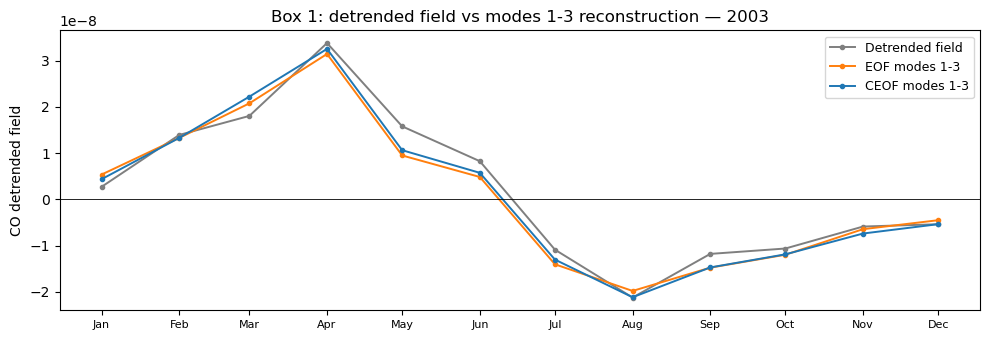

Saved -> ../Figures/no-coslat\diag_box1_recon_modes123_2003.png
Errors and ranges over all 276 months


,RMSE,MAE,Max,Min
Detrended field,—,—,3.867e-08,-2.661e-08
EOF modes 1-3,2.166e-09,1.567e-09,3.943e-08,-2.208e-08
CEOF modes 1-3,2.043e-09,1.473e-09,3.952e-08,-2.302e-08


In [34]:
BOX_K = 1

detr_ts = box_mean(detr_field, BOX_K)
eof_ts  = sum(box_mean(eofs.sel(mode=k) * pcs.sel(mode=k), BOX_K) for k in MODES_CMP)
ceof_ts = sum((cpcs.sel(mode=k) * np.conj(box_mean(ceofs.sel(mode=k), BOX_K))).real for k in MODES_CMP)

diag_table = pd.DataFrame({
    "Detrended field": detr_ts.values,
    "EOF modes 1-3":   eof_ts.values,
    "CEOF modes 1-3":  ceof_ts.values,
}, index=months.strftime("%Y-%m"))
display(diag_table.head(12).style.format("{:.3e}"))

sel_2003 = months.year == 2003
fig_d, ax_d = plt.subplots(figsize=(10, 3.5))
ax_d.plot(months[sel_2003], detr_ts.values[sel_2003], lw=1.4, marker="o", ms=3, color="#7f7f7f", label="Detrended field")
ax_d.plot(months[sel_2003], eof_ts.values[sel_2003],  lw=1.4, marker="o", ms=3, color="#ff7f0e", label="EOF modes 1-3")
ax_d.plot(months[sel_2003], ceof_ts.values[sel_2003], lw=1.4, marker="o", ms=3, color="#1f77b4", label="CEOF modes 1-3")
ax_d.axhline(0, color="k", lw=0.6)
ax_d.set_xticks(months[sel_2003])
ax_d.set_xticklabels(months[sel_2003].strftime("%b"), fontsize=8)
ax_d.set_title(f"Box {BOX_K}: detrended field vs modes 1-3 reconstruction — 2003")
ax_d.set_ylabel("CO detrended field")
ax_d.legend(fontsize=9, loc="upper right")
plt.tight_layout()
out_d = os.path.join(OUT_DIR, f"diag_box{BOX_K}_recon_modes123_2003.png")
fig_d.savefig(out_d, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_d)

err_table = pd.DataFrame({
    name: {"RMSE": np.nan if ts is detr_ts else float(np.sqrt(((ts - detr_ts) ** 2).mean())),
           "MAE":  np.nan if ts is detr_ts else float(np.abs(ts - detr_ts).mean()),
           "Max":  float(ts.max()),
           "Min":  float(ts.min())}
    for name, ts in (("Detrended field", detr_ts), ("EOF modes 1-3", eof_ts), ("CEOF modes 1-3", ceof_ts))
}).T
print(f"Errors and ranges over all {detr_ts.sizes['time']} months")
display(err_table.style.format("{:.3e}", na_rep="—"))

### Why is EOF mode 1 r² higher outside box 1?

,Box 1,Other box
pixels,25,50
mean |EOF1 loading|,3.296e-02,2.414e-02
var(detrended),1.992e-16,1.006e-16
var(mode 1 part),1.763e-16,9.449e-17
var(everything else),2.292e-17,6.063e-18
"max |2 cov(mode 1, else)|",8.213e-31,4.865e-31
var(mode 1) / var(detrended),0.885,0.940
r² with box 1 index,0.885,0.940


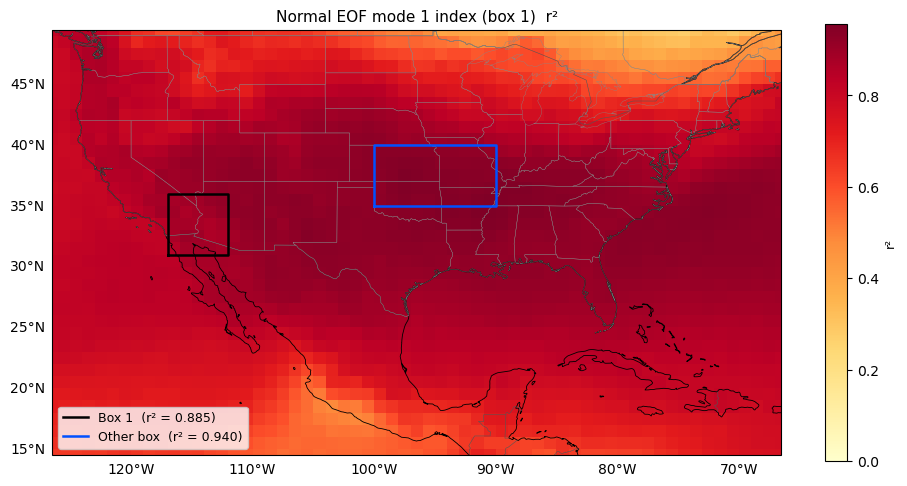

Saved -> ../Figures/no-coslat\diag_r2_eof_mode1_box1_vs_other.png


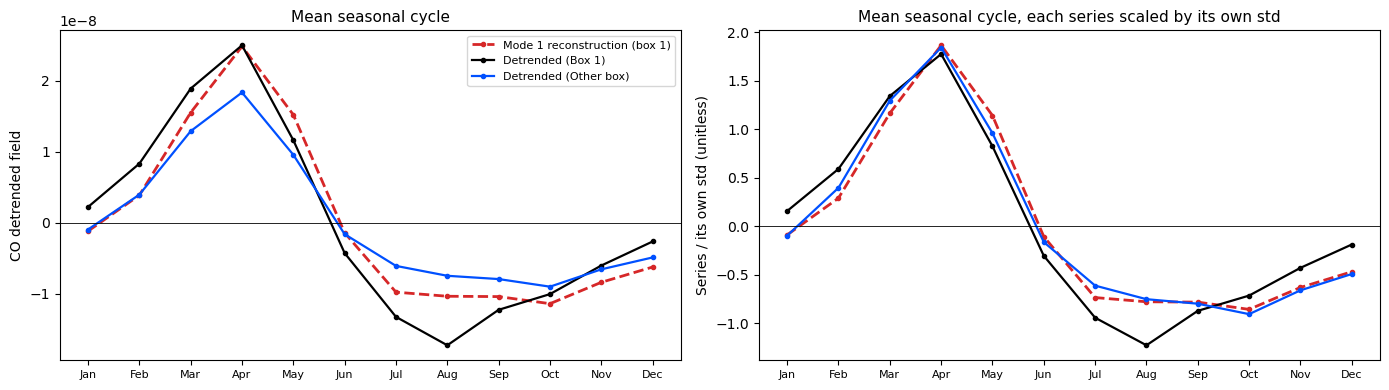

Saved -> ../Figures/no-coslat\diag_seasonal_mode1_box1_vs_other.png


In [37]:
DIAG_BOXES = {
    "Box 1":     BOXES[1],
    "Other box": dict(LAT0=35, LAT1=40, LON0=-100, LON1=-90),
}

idx_eof_1   = box_mean(eofs.sel(mode=1) * pcs.sel(mode=1), 1)
recon_eof_1 = eofs.sel(mode=1) * pcs.sel(mode=1)

rows = {}
for name, b in DIAG_BOXES.items():
    box_sel = dict(lat=slice(b["LAT0"], b["LAT1"]), lon=slice(b["LON0"], b["LON1"]))
    Y = detr_field.sel(**box_sel)                 # detrended series at each pixel
    M = recon_eof_1.sel(**box_sel)                # mode 1 part at each pixel
    R = Y - M                                     # everything else (modes 2, 3, ... )

    var_Y = Y.var("time")
    var_M = M.var("time")
    var_R = R.var("time")
    cov_MR = ((M - M.mean("time")) * (R - R.mean("time"))).mean("time")

    rows[name] = {
        "pixels":                       int(var_Y.count()),
        "mean |EOF1 loading|":          float(np.abs(eofs.sel(mode=1).sel(**box_sel)).mean()),
        "var(detrended)":               float(var_Y.mean()),
        "var(mode 1 part)":             float(var_M.mean()),
        "var(everything else)":         float(var_R.mean()),
        "max |2 cov(mode 1, else)|":    float(np.abs(2 * cov_MR).max()),
        "var(mode 1) / var(detrended)": float((var_M / var_Y).mean()),
        "r² with box 1 index":          float((xr.corr(Y, idx_eof_1, dim="time") ** 2).mean()),
    }

diag_var = pd.DataFrame(rows)
display(diag_var.style.format("{:.3e}").format("{:.3f}", subset=pd.IndexSlice[
    ["var(mode 1) / var(detrended)", "r² with box 1 index"], :]).format("{:.0f}", subset=pd.IndexSlice[["pixels"], :]))

# ratio = diag_var.loc[["mean |EOF1 loading|", "var(mode 1 part)", "var(everything else)"], "Box 1"] / \
#         diag_var.loc[["mean |EOF1 loading|", "var(mode 1 part)", "var(everything else)"], "Other box"]
# print("Box 1 / Other box:")
# print(ratio.round(2).to_string())

diag_box_colors = {"Box 1": "k", "Other box": "#0050ff"}
r2_eof_1 = r2_maps["eof"][1].values

fig_dr, ax_dr = plt.subplots(figsize=(9, 5.5), subplot_kw={"projection": ccrs.PlateCarree()},
                             constrained_layout=True)
ax_dr.set_extent(ext, crs=ccrs.PlateCarree())
ax_dr.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
ax_dr.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
ax_dr.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")
pcm = ax_dr.pcolormesh(lons, lats, r2_eof_1, transform=ccrs.PlateCarree(),
                       cmap="YlOrRd", vmin=0, vmax=np.nanmax(r2_eof_1), shading="nearest")
gl = ax_dr.gridlines(draw_labels=True, linewidth=0, color="none")
gl.top_labels = gl.right_labels = False

for name, b in DIAG_BOXES.items():
    ax_dr.plot([b["LON0"], b["LON1"], b["LON1"], b["LON0"], b["LON0"]],
               [b["LAT0"], b["LAT0"], b["LAT1"], b["LAT1"], b["LAT0"]],
               "-", color=diag_box_colors[name], lw=1.8, transform=ccrs.PlateCarree(),
               label=f"{name}  (r² = {rows[name]['r² with box 1 index']:.3f})")
ax_dr.legend(fontsize=9, loc="lower left")

cb = fig_dr.colorbar(pcm, ax=ax_dr, orientation="vertical", fraction=0.03, pad=0.06)
cb.set_label("r²", fontsize=9)
ax_dr.set_title("Normal EOF mode 1 index (box 1)  r²", fontsize=11, pad=6)
out_dr = os.path.join(OUT_DIR, "diag_r2_eof_mode1_box1_vs_other.png")
fig_dr.savefig(out_dr, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_dr)

seas = pd.DataFrame({
    "Mode 1 reconstruction (box 1)": idx_eof_1.values,
    **{f"Detrended ({name})": detr_field.sel(lat=slice(b["LAT0"], b["LAT1"]), lon=slice(b["LON0"], b["LON1"]))
                                         .mean(("lat", "lon")).values
       for name, b in DIAG_BOXES.items()},
}, index=months)
seas_mean = seas.groupby(seas.index.month).mean()
seas_norm = (seas / seas.std()).groupby(seas.index.month).mean()

seas_styles = {
    "Mode 1 reconstruction (box 1)": dict(color="#d62728", lw=2.0, ls="--"),
    "Detrended (Box 1)":             dict(color=diag_box_colors["Box 1"], lw=1.6),
    "Detrended (Other box)":         dict(color=diag_box_colors["Other box"], lw=1.6),
}

fig_ds, axes_ds = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, ylabel, title in (
    (axes_ds[0], seas_mean, "CO detrended field",           "Mean seasonal cycle"),
    (axes_ds[1], seas_norm, "Series / its own std (unitless)", "Mean seasonal cycle, each series scaled by its own std"),
):
    for col, style in seas_styles.items():
        ax.plot(data.index, data[col].values, marker="o", ms=3, label=col, **style)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(pd.to_datetime([f"2003-{m:02d}-01" for m in range(1, 13)]).strftime("%b"), fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
axes_ds[0].legend(fontsize=8, loc="upper right")

plt.tight_layout()
out_ds = os.path.join(OUT_DIR, "diag_seasonal_mode1_box1_vs_other.png")
fig_ds.savefig(out_ds, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_ds)

## Regression coefficient maps (×100): detrended field vs mode index time series

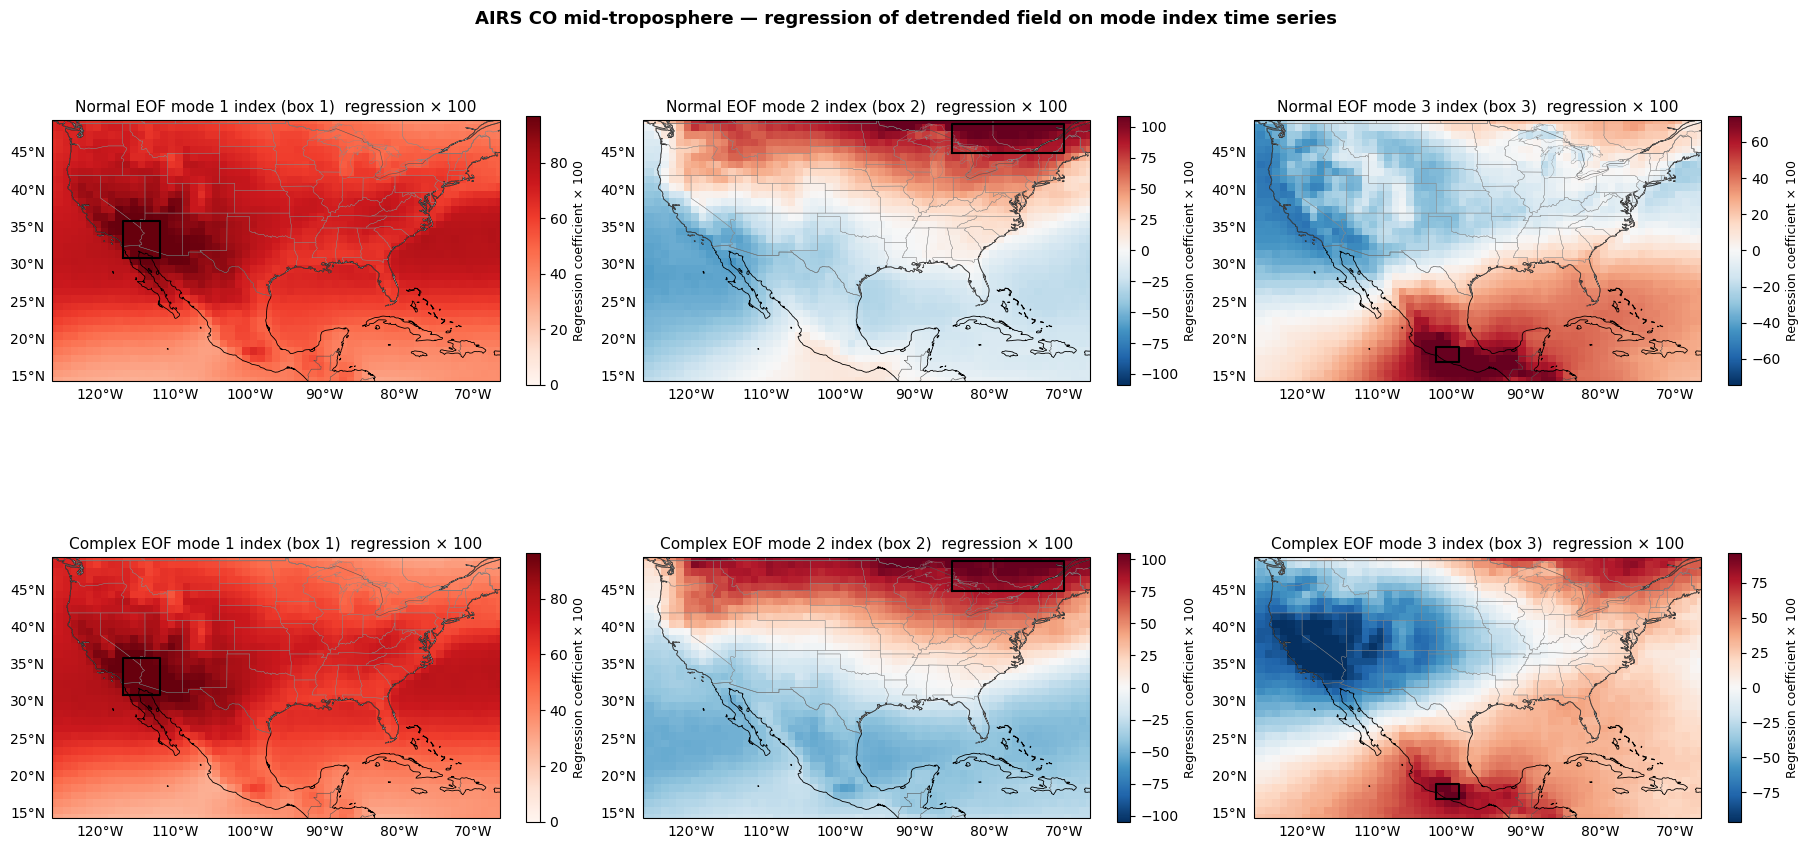

Saved -> ../Figures/no-coslat\regr_maps_index_eof_ceof_modes123.png


In [31]:
regr_maps = {"eof": {}, "ceof": {}}
for k in MODES_CMP:
    idx_eof_k  = box_mean(eofs.sel(mode=k) * pcs.sel(mode=k), k)
    ref_k      = box_mean(ceofs.sel(mode=k), k)
    idx_ceof_k = (cpcs.sel(mode=k) * np.conj(ref_k)).real
    for kind, idx_k in (("eof", idx_eof_k), ("ceof", idx_ceof_k)):
        regr_maps[kind][k] = 100 * xr.cov(detr_field, idx_k, dim="time") / xr.cov(idx_k, idx_k, dim="time")

fig_rg, axes_rg = plt.subplots(
    2, 3, figsize=(18, 9),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True,
)

for row, kind in enumerate(("eof", "ceof")):
    name = "Normal EOF" if kind == "eof" else "Complex EOF"
    for col, k in enumerate(MODES_CMP):
        ax = axes_rg[row, col]
        regr_k = regr_maps[kind][k].values
        cmap_k, vmin_k, vmax_k = choose_cmap_and_range(regr_k)

        ax.set_extent(ext, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
        ax.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")
        pcm = ax.pcolormesh(lons, lats, regr_k, transform=ccrs.PlateCarree(),
                            cmap=cmap_k, vmin=vmin_k, vmax=vmax_k, shading="nearest")
        gl = ax.gridlines(draw_labels=True, linewidth=0, color="none")
        gl.top_labels = gl.right_labels = False

        b = BOXES[k]
        ax.plot([b["LON0"], b["LON1"], b["LON1"], b["LON0"], b["LON0"]],
                [b["LAT0"], b["LAT0"], b["LAT1"], b["LAT1"], b["LAT0"]],
                "k-", lw=1.5, transform=ccrs.PlateCarree())

        cb = fig_rg.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)
        cb.set_label("Regression coefficient × 100", fontsize=9)
        ax.set_title(f"{name} mode {k} index (box {k})  regression × 100", fontsize=11, pad=6)

fig_rg.suptitle("AIRS CO mid-troposphere — regression of detrended field on mode index time series",
                fontsize=13, fontweight="bold")
out_rg = os.path.join(OUT_DIR, "regr_maps_index_eof_ceof_modes123.png")
fig_rg.savefig(out_rg, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_rg)